<h1 style="color:red; text-align:center;">
DRIVE RETINAL VESSEL SEGMENTATION USING TOPOLOGY-AWARE TRANSFER LEARNING
</h1>

## Overview

In this experiment, a topology-aware road segmentation model was transferred to the DRIVE retinal vessel segmentation dataset. The goal was to investigate whether a model trained to preserve road connectivity could also learn the topology and branching structure of retinal blood vessels.

The pretrained source model used in this experiment was:

- **Road Model 5**
- **BCE + Dice + soft-clDice + SATLoss Creator**

The experiment focused on preserving vessel continuity, branching structures, and topological consistency during retinal vessel segmentation.

---

# Dataset Preparation

The DRIVE dataset contains retinal fundus images together with manually annotated vessel masks and field-of-view (FOV) masks.

The original image size was:

- **584 × 565**

Since the pretrained road model was trained using **96 × 96** image patches, the retinal images were also divided into overlapping patches of size:

- **Patch size = 96 × 96**
- **Stride = 48**

The preprocessing pipeline included:

- Normalization of RGB retinal images to the range **[0,1]**
- Conversion of vessel masks into binary masks
- Removal of low-FOV patches outside the retinal region
- Overlapping patch extraction for dense vessel learning

---

# Dataset Statistics

## Full Images

- **20 retinal images**
- **20 vessel masks**
- **20 FOV masks**

## Patch Statistics

| Split | Number of Patches |
|---|---:|
| Training | 1301 |
| Validation | 278 |
| Testing | 280 |

Additional statistics:

- Mean vessel ratio: approximately **12%**
- Mean FOV ratio: approximately **93%**

The extracted patches contained both thick and thin retinal vessels, vessel bifurcations, and complex vascular trees.

---

# Transfer Learning Strategy

The pretrained road segmentation model was directly transferred to retinal vessel segmentation.

The experiment was performed in two stages:

---

# Stage 1: DRIVE Transfer Learning

In the first stage, the pretrained road model was fine-tuned on DRIVE retinal patches using the hybrid segmentation loss:

$$
\mathcal{L}
=
\mathcal{L}_{BCE}
+
\mathcal{L}_{Dice}
+
\mathcal{L}_{clDice}
$$

where:

- **Binary Cross Entropy (BCE)** improves pixel-wise vessel classification
- **Dice Loss** improves overlap between prediction and ground truth
- **soft-clDice** improves vessel connectivity and continuity

The model was trained for:

- **30 epochs**
- Learning rate: **1e-4**

The best validation model was automatically saved using validation Dice score.

---

# Stage 2: SATLoss Creator Fine-Tuning

In the second stage, SATLoss Creator was added for topology refinement.

The loss became:

$$
\mathcal{L}
=
\mathcal{L}_{BCE}
+
\mathcal{L}_{Dice}
+
\mathcal{L}_{clDice}
+
\lambda \mathcal{L}_{SAT}
$$

where:

- $\mathcal{L}_{SAT}$ is the Spatial-Aware Topological Loss
- SATLoss compares persistent topological features between prediction and ground truth
- Creator matching was used to preserve important topological structures

The SATLoss refinement stage was trained using a smaller learning rate:

- **Learning rate = 5e-5**

---

# Patch-Level Test Results

## Final DRIVE Transfer Model

| Metric | Value |
|---|---:|
| Accuracy | 0.9518 |
| Dice | 0.7976 |
| clDice | 0.7828 |
| $\beta_0$ Error | 1.4179 |
| $\beta_1$ Error | 0.7107 |

---

# Full-Image Prediction Results

Whole-image retinal vessel predictions were reconstructed using sliding-window inference.

The full-image prediction pipeline included:

1. Dividing full retinal images into overlapping patches
2. Predicting vessel probabilities for each patch
3. Stitching overlapping predictions together
4. Averaging overlapping probability regions
5. Applying the FOV mask
6. Generating the final vessel segmentation mask

## Mean Full-Image Results

| Metric | Value |
|---|---:|
| Accuracy | 0.9658 |
| Dice | 0.7985 |
| clDice | 0.8010 |

The full-image predictions successfully preserved the major retinal vessel trees and vessel connectivity across the retina.

---

# Visual Analysis

The prediction visualizations showed that the transferred topology-aware model successfully learned retinal vessel geometry.

The model was able to:

- Preserve vessel continuity
- Detect vessel bifurcations
- Maintain large connected vessel structures
- Detect many thin vessels
- Produce smooth vessel boundaries

The overlay visualizations demonstrated strong alignment between predicted vessels and the ground-truth annotations.

The whole-image predictions further confirmed that topology-aware transfer learning generalized well from road segmentation to retinal vessel segmentation.

---

# Observations on SATLoss Refinement

The additional SATLoss refinement stage did not significantly improve the DRIVE results.

This observation suggests that:

- The pretrained Road Model 5 had already learned strong topology-preserving features
- The initial transfer-learning stage was sufficient for adapting the topology-aware representations to retinal vessels
- Additional SATLoss refinement slightly over-constrained the optimization process

This result is scientifically meaningful because it demonstrates that topology-aware features learned from road segmentation can generalize effectively to biomedical vessel segmentation without requiring excessive topological refinement.

---

# Conclusion

This experiment demonstrated that topology-aware transfer learning can successfully generalize across very different image domains.

A road segmentation model trained using:

- BCE
- Dice
- soft-clDice
- SATLoss Creator

was successfully adapted to retinal vessel segmentation in the DRIVE dataset.

The final model achieved:

- Strong Dice and clDice performance
- Good vessel continuity
- Stable vessel branching structures
- High-quality full-image vessel predictions

The experiment further showed that topology-aware pretrained representations can transfer effectively from road networks to retinal vascular structures while preserving important connectivity information.

In [1]:
# ============================================================
# STEP 1: Setup environment and download DRIVE retina dataset
# ============================================================
# This notebook uses Road Model 5 as the transfer-learning backbone:
#     best_hybrid_sat_creator_model.pth
#
# Source model:
#     Road segmentation model trained with
#     BCE + Dice + soft-clDice + SATLoss Creator
#
# Target task:
#     Retinal vessel segmentation on DRIVE dataset
#
# Goal of this step:
#   1. Import all required libraries
#   2. Set random seeds
#   3. Select GPU if available
#   4. Download and extract DRIVE retina dataset
#   5. Create folders for models, results, and figures
# ============================================================

# ----------------------------
# Install required packages
# ----------------------------
import sys

!{sys.executable} -m pip install --upgrade gdown -q
!{sys.executable} -m pip install gudhi -q

# ----------------------------
# Standard libraries
# ----------------------------
import os
import random
import zipfile
import copy
import json
import pickle
import time
import re
from glob import glob

# ----------------------------
# Numerical and visualization libraries
# ----------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm

# ----------------------------
# PyTorch libraries
# ----------------------------
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

# ----------------------------
# Image processing and topology libraries
# ----------------------------
import gudhi

from scipy.optimize import linear_sum_assignment
from scipy.ndimage import binary_fill_holes

from skimage.morphology import skeletonize
from skimage.measure import label
from skimage import exposure

# ----------------------------
# Google Drive downloader
# ----------------------------
import gdown


# ============================================================
# Reproducibility
# ============================================================
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# ============================================================
# Device
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ============================================================
# Main settings
# ============================================================
PATCH_SIZE = 96
STRIDE = 48
BATCH_SIZE = 8

# Pretrained road model selected for transfer learning
PRETRAINED_ROAD_MODEL_PATH = (
    "/home/mutie/final_thesis_models/"
    "best_hybrid_sat_creator_model.pth"
)


# ============================================================
# Output folders
# ============================================================
SAVE_DIR = "drive_transfer_models"
RESULTS_DIR = "drive_transfer_results"
FIGURE_DIR = "drive_transfer_figures"

os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(FIGURE_DIR, exist_ok=True)


# ============================================================
# Download DRIVE retina dataset from Google Drive
# ============================================================

drive_file_id = "1nrfMiJHKVNctsaY9sskBim1FsToaHasp"
drive_url = f"https://drive.google.com/uc?id={drive_file_id}"

zip_path = "drive_retina_images.zip"

if not os.path.exists(zip_path):
    print("Downloading DRIVE retina dataset...")
    gdown.download(drive_url, zip_path, quiet=False)
else:
    print("Dataset zip already exists:", zip_path)


# ----------------------------
# Check downloaded file
# ----------------------------
if os.path.exists(zip_path):
    print("\nDownloaded file")
    print("---------------")
    print(
        zip_path,
        "| exists:",
        True,
        "| size:",
        round(os.path.getsize(zip_path) / (1024 ** 2), 2),
        "MB"
    )
else:
    raise FileNotFoundError("DRIVE retina zip file was not downloaded correctly.")


# ============================================================
# Extract dataset
# ============================================================

extract_dir = "drive_retina_images"

if not os.path.exists(extract_dir):
    print("\nExtracting DRIVE retina dataset...")
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_dir)
    print("Extraction finished.")
else:
    print("\nDataset already extracted.")


# ============================================================
# Inspect extracted folders
# ============================================================

print("\nExtracted folder structure")
print("--------------------------")

for root, dirs, files in os.walk(extract_dir):
    level = root.replace(extract_dir, "").count(os.sep)
    indent = "  " * level

    image_like_files = [
        f for f in files
        if f.lower().endswith((".png", ".jpg", ".jpeg", ".tif", ".tiff", ".gif"))
    ]

    print(f"{indent}{os.path.basename(root)}/")

    if len(image_like_files) > 0:
        print(f"{indent}  Number of image files:", len(image_like_files))
        print(f"{indent}  Examples:", image_like_files[:5])

    # Prevent printing too deeply
    if level >= 3:
        dirs[:] = []


# ============================================================
# Final setup summary
# ============================================================

print("\nSETUP SUMMARY")
print("-------------")
print("Device:", device)
print("Gudhi version:", gudhi.__version__)
print("Patch size:", PATCH_SIZE)
print("Stride:", STRIDE)
print("Batch size:", BATCH_SIZE)
print("Pretrained road model path:", PRETRAINED_ROAD_MODEL_PATH)
print("Model save folder:", SAVE_DIR)
print("Results folder:", RESULTS_DIR)
print("Figures folder:", FIGURE_DIR)

Downloading...
From (original): https://drive.google.com/uc?id=1nrfMiJHKVNctsaY9sskBim1FsToaHasp
From (redirected): https://drive.google.com/uc?id=1nrfMiJHKVNctsaY9sskBim1FsToaHasp&confirm=t&uuid=ddda29e9-b3c5-4ef4-8726-a573dda5774c
To: /home/mutie/final_thesis_figures/drive_retina_images.zip
100%|██████████| 29.4M/29.4M [00:04<00:00, 6.27MB/s]



Downloaded file
---------------
drive_retina_images.zip | exists: True | size: 27.99 MB

Extracting DRIVE retina dataset...
Extraction finished.

Extracted folder structure
--------------------------
drive_retina_images/
  DRIVE/
    training/
      1st_manual/
        Number of image files: 20
        Examples: ['32_manual1.gif', '25_manual1.gif', '29_manual1.gif', '28_manual1.gif', '21_manual1.gif']
      mask/
        Number of image files: 20
        Examples: ['28_training_mask.gif', '22_training_mask.gif', '21_training_mask.gif', '38_training_mask.gif', '27_training_mask.gif']
      images/
        Number of image files: 20
        Examples: ['21_training.tif', '39_training.tif', '35_training.tif', '29_training.tif', '32_training.tif']
    test/
      mask/
        Number of image files: 20
        Examples: ['06_test_mask.gif', '11_test_mask.gif', '03_test_mask.gif', '18_test_mask.gif', '01_test_mask.gif']
      images/
        Number of image files: 20
        Examples: ['15_t

In [2]:
# ============================================================
# STEP 2: Create DRIVE image-vessel mask pairs and inspect sizes
# ============================================================
# DRIVE contains:
#   training/images      -> retinal fundus images
#   training/1st_manual  -> manual vessel ground-truth masks
#   training/mask        -> field-of-view masks
#
# Since the test folder does not include manual vessel masks in this zip,
# we use the 20 training images and split them ourselves later.
# ============================================================

drive_root = "drive_retina_images/DRIVE"

train_img_dir = os.path.join(drive_root, "training", "images")
train_vessel_dir = os.path.join(drive_root, "training", "1st_manual")
train_fov_dir = os.path.join(drive_root, "training", "mask")

image_files = sorted(glob(os.path.join(train_img_dir, "*.tif")))
vessel_files = sorted(glob(os.path.join(train_vessel_dir, "*.gif")))
fov_files = sorted(glob(os.path.join(train_fov_dir, "*.gif")))

print("Training images:", len(image_files))
print("Vessel masks   :", len(vessel_files))
print("FOV masks      :", len(fov_files))


def get_drive_id(path):
    """
    Extract DRIVE image ID.

    Examples:
        21_training.tif       -> 21
        21_manual1.gif        -> 21
        21_training_mask.gif  -> 21
    """
    name = os.path.basename(path)
    match = re.search(r"(\d+)", name)

    if match is None:
        return None

    return match.group(1)


image_dict = {
    get_drive_id(path): path
    for path in image_files
}

vessel_dict = {
    get_drive_id(path): path
    for path in vessel_files
}

fov_dict = {
    get_drive_id(path): path
    for path in fov_files
}


drive_pairs = []
missing_vessel = []
missing_fov = []

for image_id in sorted(image_dict.keys()):
    if image_id not in vessel_dict:
        missing_vessel.append(image_id)
        continue

    if image_id not in fov_dict:
        missing_fov.append(image_id)
        continue

    drive_pairs.append({
        "image_id": image_id,
        "image_path": image_dict[image_id],
        "vessel_mask_path": vessel_dict[image_id],
        "fov_mask_path": fov_dict[image_id]
    })


print("\nPAIRING SUMMARY")
print("---------------")
print("Matched image-vessel-FOV pairs:", len(drive_pairs))
print("Missing vessel masks:", missing_vessel)
print("Missing FOV masks   :", missing_fov)


# ============================================================
# Inspect original image and mask sizes
# ============================================================

size_records = []

for pair in drive_pairs:
    image = Image.open(pair["image_path"])
    vessel_mask = Image.open(pair["vessel_mask_path"])
    fov_mask = Image.open(pair["fov_mask_path"])

    size_records.append({
        "image_id": pair["image_id"],
        "image_size": image.size,
        "vessel_mask_size": vessel_mask.size,
        "fov_mask_size": fov_mask.size
    })

size_df = pd.DataFrame(size_records)

print("\nOriginal size summary")
print("---------------------")
display(size_df)

print("\nUnique image sizes:", size_df["image_size"].unique())
print("Unique vessel mask sizes:", size_df["vessel_mask_size"].unique())
print("Unique FOV mask sizes:", size_df["fov_mask_size"].unique())


# ============================================================
# Show example pairs
# ============================================================

print("\nExample matched pairs")
print("---------------------")

for pair in drive_pairs[:5]:
    print(
        pair["image_id"],
        " | ",
        os.path.basename(pair["image_path"]),
        " -> ",
        os.path.basename(pair["vessel_mask_path"]),
        " | FOV:",
        os.path.basename(pair["fov_mask_path"])
    )


# ============================================================
# Save pairing summary
# ============================================================

drive_pairing_df = pd.DataFrame(drive_pairs)

pairing_path = os.path.join(
    RESULTS_DIR,
    "drive_training_image_vessel_pairs.csv"
)

drive_pairing_df.to_csv(pairing_path, index=False)

print("\nSaved DRIVE pairing summary to:")
print(pairing_path)

Training images: 20
Vessel masks   : 20
FOV masks      : 20

PAIRING SUMMARY
---------------
Matched image-vessel-FOV pairs: 20
Missing vessel masks: []
Missing FOV masks   : []

Original size summary
---------------------


,image_id,image_size,vessel_mask_size,fov_mask_size
0,21,"(565, 584)","(565, 584)","(565, 584)"
1,22,"(565, 584)","(565, 584)","(565, 584)"
2,23,"(565, 584)","(565, 584)","(565, 584)"
3,24,"(565, 584)","(565, 584)","(565, 584)"
4,25,"(565, 584)","(565, 584)","(565, 584)"
5,26,"(565, 584)","(565, 584)","(565, 584)"
6,27,"(565, 584)","(565, 584)","(565, 584)"
7,28,"(565, 584)","(565, 584)","(565, 584)"
8,29,"(565, 584)","(565, 584)","(565, 584)"
9,30,"(565, 584)","(565, 584)","(565, 584)"



Unique image sizes: [(565, 584)]
Unique vessel mask sizes: [(565, 584)]
Unique FOV mask sizes: [(565, 584)]

Example matched pairs
---------------------
21  |  21_training.tif  ->  21_manual1.gif  | FOV: 21_training_mask.gif
22  |  22_training.tif  ->  22_manual1.gif  | FOV: 22_training_mask.gif
23  |  23_training.tif  ->  23_manual1.gif  | FOV: 23_training_mask.gif
24  |  24_training.tif  ->  24_manual1.gif  | FOV: 24_training_mask.gif
25  |  25_training.tif  ->  25_manual1.gif  | FOV: 25_training_mask.gif

Saved DRIVE pairing summary to:
drive_transfer_results/drive_training_image_vessel_pairs.csv



Example 1
Image ID: 24
Image: 24_training.tif
Vessel mask: 24_manual1.gif
FOV mask: 24_training_mask.gif
Image shape: (584, 565, 3)
Vessel ratio: 0.11585949812098437
FOV ratio: 0.6901624439325978


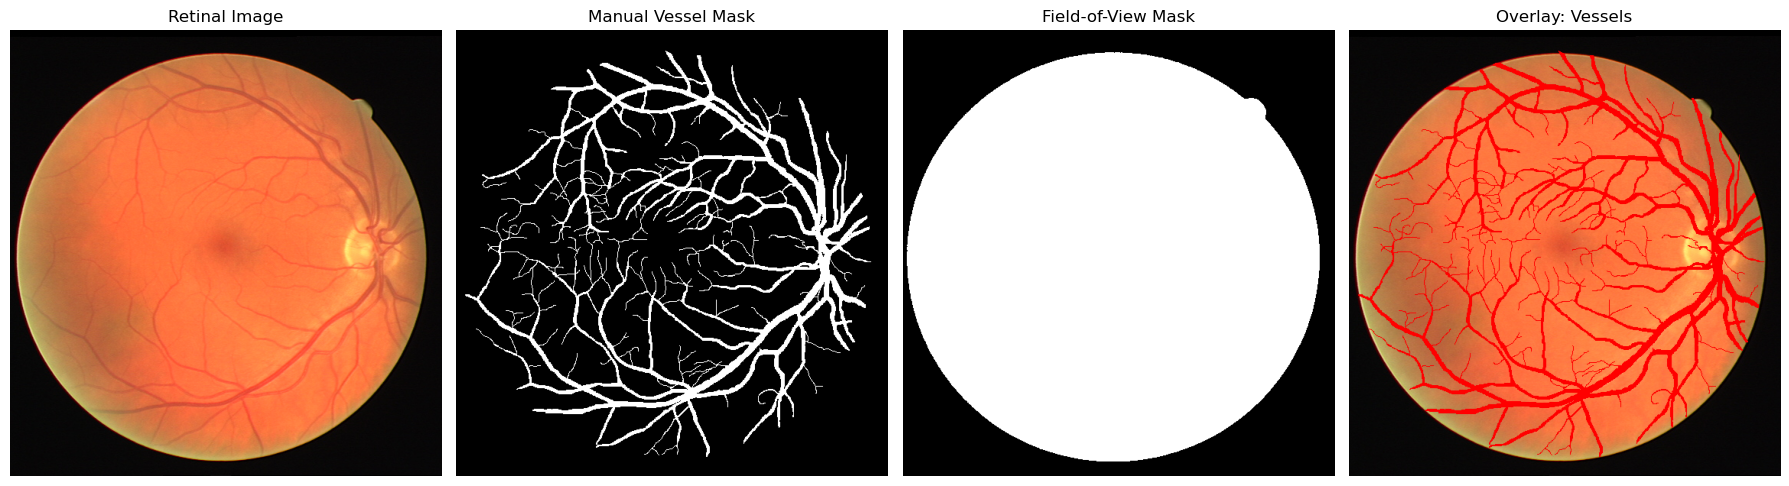

Saved figure: drive_transfer_figures/step3_drive_pair_example_1.png

Example 2
Image ID: 21
Image: 21_training.tif
Vessel mask: 21_manual1.gif
FOV mask: 21_training_mask.gif
Image shape: (584, 565, 3)
Vessel ratio: 0.07473027033579828
FOV ratio: 0.6837192386955995


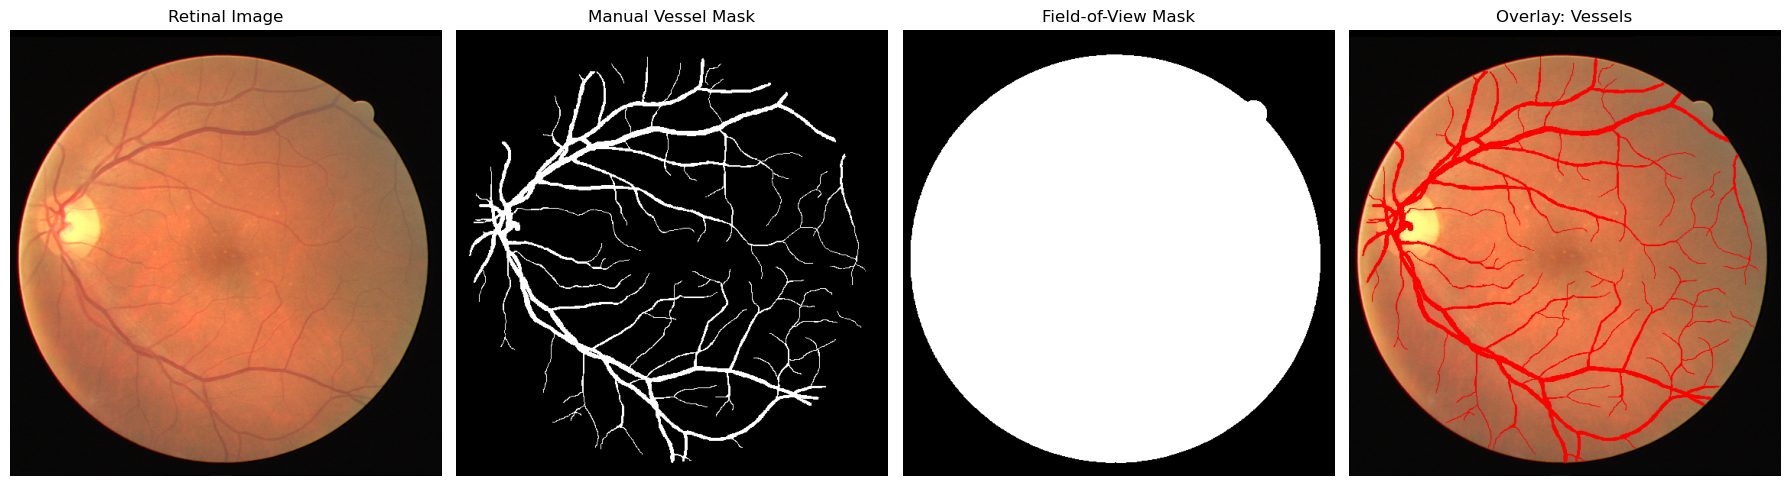

Saved figure: drive_transfer_figures/step3_drive_pair_example_2.png

Example 3
Image ID: 29
Image: 29_training.tif
Vessel mask: 29_manual1.gif
FOV mask: 29_training_mask.gif
Image shape: (584, 565, 3)
Vessel ratio: 0.08410413383440417
FOV ratio: 0.6888986543823494


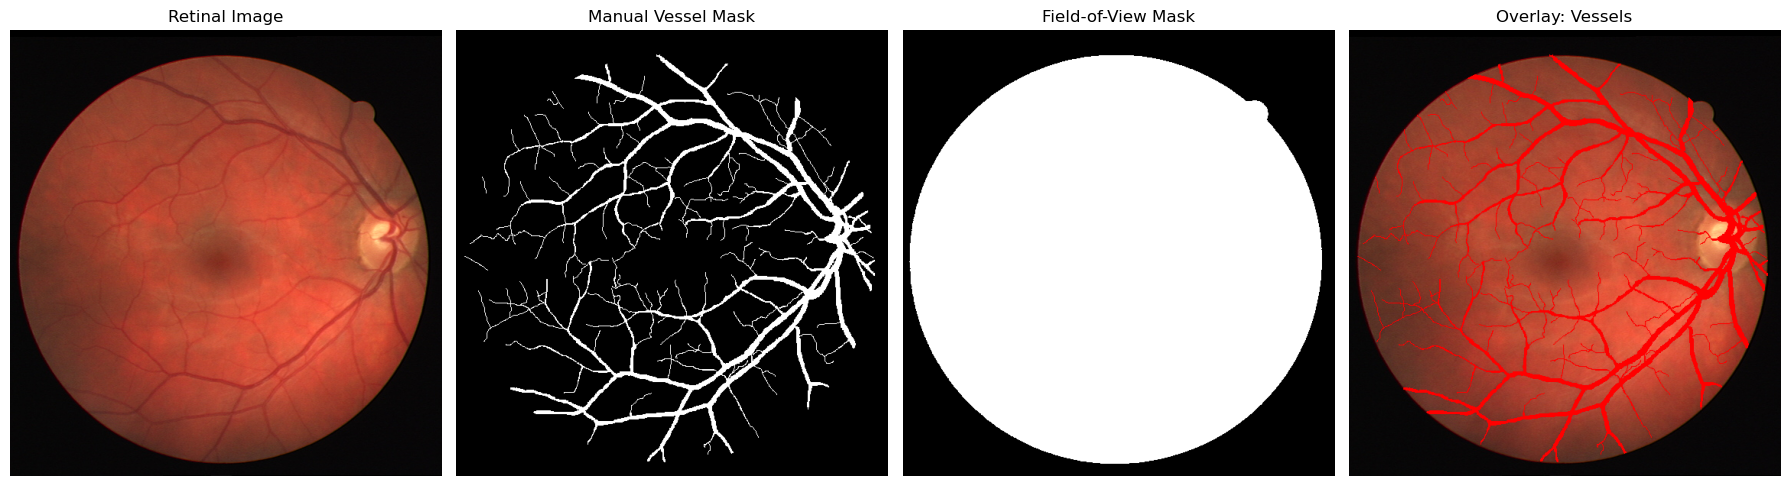

Saved figure: drive_transfer_figures/step3_drive_pair_example_3.png

Example 4
Image ID: 28
Image: 28_training.tif
Vessel mask: 28_manual1.gif
FOV mask: 28_training_mask.gif
Image shape: (584, 565, 3)
Vessel ratio: 0.09767244514486605
FOV ratio: 0.6889532064492666


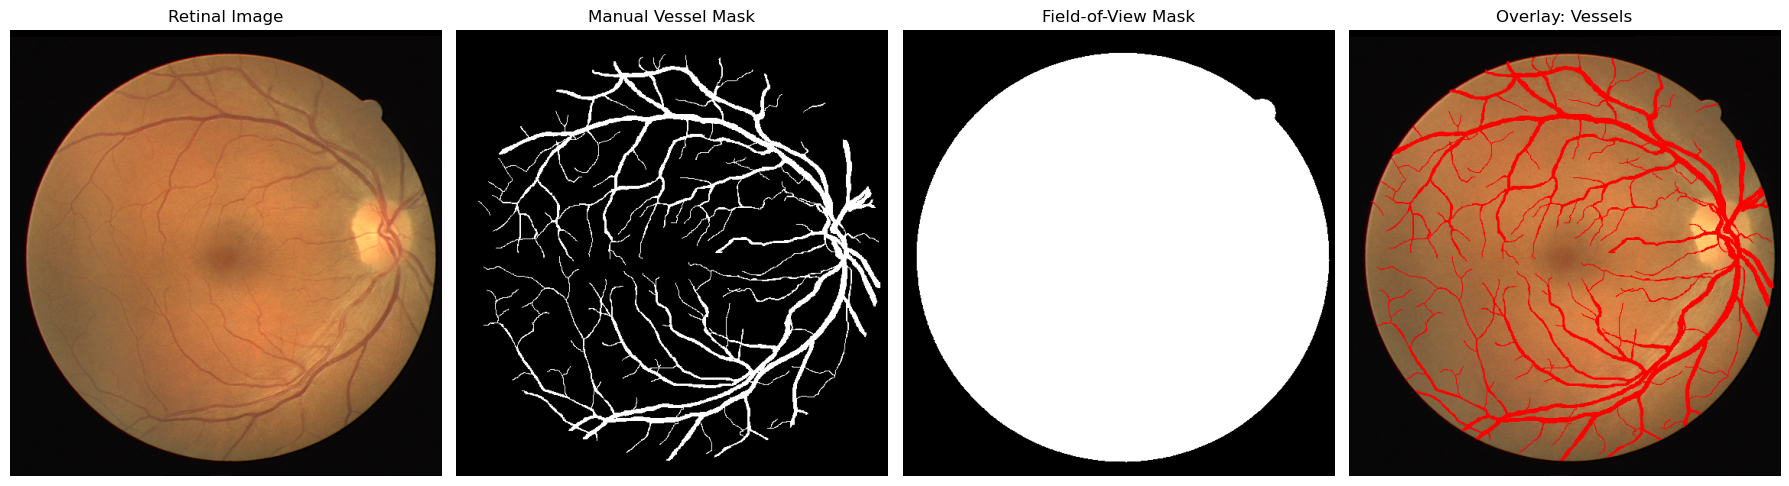

Saved figure: drive_transfer_figures/step3_drive_pair_example_4.png

Example 5
Image ID: 37
Image: 37_training.tif
Vessel mask: 37_manual1.gif
FOV mask: 37_training_mask.gif
Image shape: (584, 565, 3)
Vessel ratio: 0.08740756455327918
FOV ratio: 0.6885258819250818


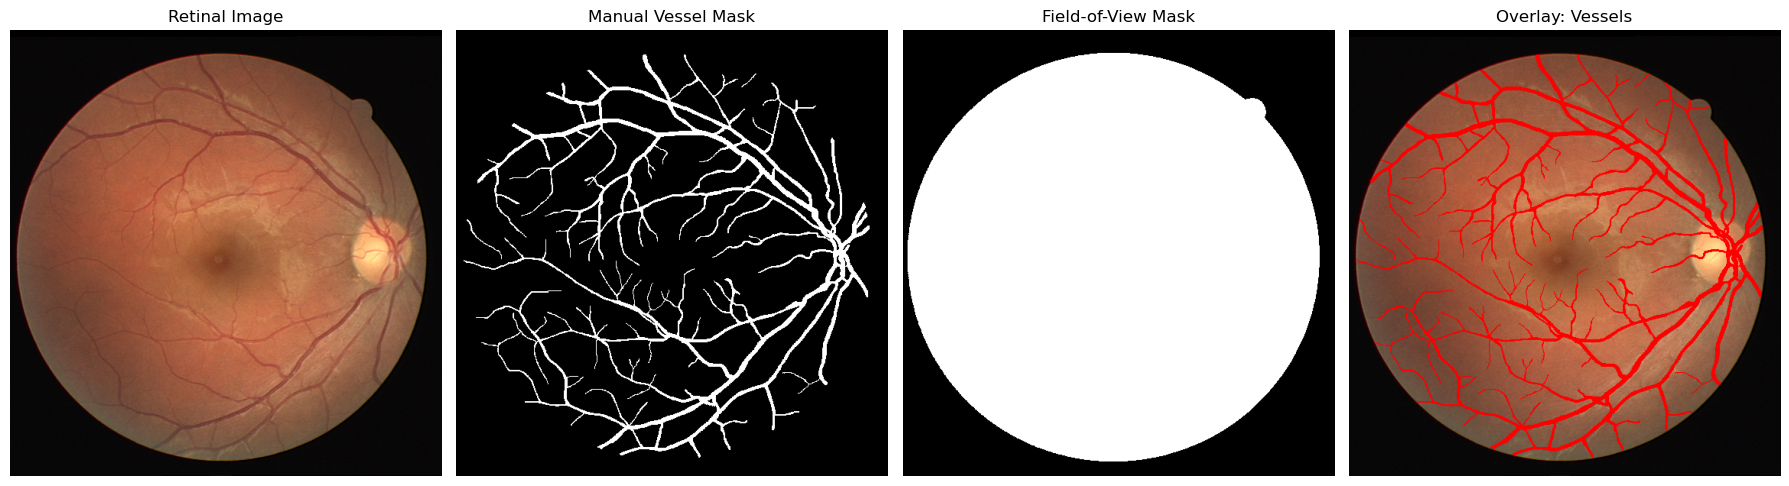

Saved figure: drive_transfer_figures/step3_drive_pair_example_5.png


In [3]:
# ============================================================
# STEP 3: Visualize DRIVE image, vessel mask, FOV mask, and overlay
# ============================================================
# This step checks whether the retinal image, vessel annotation,
# and field-of-view mask are correctly aligned.
#
# Columns:
#   Retinal Image | Vessel Mask | FOV Mask | Vessel Overlay
#
# Red overlay = manual vessel pixels.
# ============================================================

num_examples = 5

selected_pairs = random.sample(
    drive_pairs,
    min(num_examples, len(drive_pairs))
)

for count, pair in enumerate(selected_pairs, start=1):

    image = Image.open(pair["image_path"]).convert("RGB")
    vessel_mask = Image.open(pair["vessel_mask_path"]).convert("L")
    fov_mask = Image.open(pair["fov_mask_path"]).convert("L")

    image_np = np.array(image).astype(np.float32) / 255.0
    vessel_np = (np.array(vessel_mask) > 0).astype(np.uint8)
    fov_np = (np.array(fov_mask) > 0).astype(np.uint8)

    overlay = image_np.copy()
    overlay[vessel_np == 1] = [1.0, 0.0, 0.0]

    print(f"\nExample {count}")
    print("Image ID:", pair["image_id"])
    print("Image:", os.path.basename(pair["image_path"]))
    print("Vessel mask:", os.path.basename(pair["vessel_mask_path"]))
    print("FOV mask:", os.path.basename(pair["fov_mask_path"]))
    print("Image shape:", image_np.shape)
    print("Vessel ratio:", vessel_np.mean())
    print("FOV ratio:", fov_np.mean())

    plt.figure(figsize=(18, 5))

    plt.subplot(1, 4, 1)
    plt.imshow(image_np)
    plt.title("Retinal Image")
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(vessel_np, cmap="gray")
    plt.title("Manual Vessel Mask")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(fov_np, cmap="gray")
    plt.title("Field-of-View Mask")
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.imshow(overlay)
    plt.title("Overlay: Vessels")
    plt.axis("off")

    plt.tight_layout()

    save_path = os.path.join(
        FIGURE_DIR,
        f"step3_drive_pair_example_{count}.png"
    )

    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved figure:", save_path)

In [4]:
# ============================================================
# STEP 4: Extract 96x96 overlapping DRIVE vessel patches
# ============================================================
# This step creates training patches from the DRIVE retinal images.
#
# We extract:
#   - image patches from retinal RGB images
#   - vessel mask patches from manual annotations
#   - FOV mask patches from field-of-view masks
#
# Why FOV mask is important:
#   DRIVE images contain black background outside the circular retina.
#   We avoid training mostly on this black area by keeping only patches
#   that contain enough valid retinal field-of-view pixels.
#
# Patch settings:
#   Patch size = 96x96
#   Stride     = 48
# ============================================================

# ----------------------------
# Patch filtering settings
# ----------------------------
MIN_FOV_RATIO = 0.50        # Keep patches where at least 50% is inside retina
MIN_VESSEL_RATIO = 0.005    # Keep vessel patches with enough vessel pixels
EMPTY_KEEP_RATIO = 0.05     # Keep a small number of non-vessel patches


def normalize_drive_image(image_np):
    """
    Normalize RGB retinal image to [0, 1].
    """

    image_np = image_np.astype(np.float32) / 255.0

    return image_np


def extract_drive_patches_from_pair(
    pair,
    patch_size=96,
    stride=48,
    min_fov_ratio=0.50,
    min_vessel_ratio=0.005,
    empty_keep_ratio=0.05
):
    """
    Extract DRIVE image, vessel mask, and FOV mask patches from one image.
    """

    image = Image.open(pair["image_path"]).convert("RGB")
    vessel_mask = Image.open(pair["vessel_mask_path"]).convert("L")
    fov_mask = Image.open(pair["fov_mask_path"]).convert("L")

    image_np = normalize_drive_image(
        np.array(image)
    )

    vessel_np = (
        np.array(vessel_mask) > 0
    ).astype(np.float32)

    fov_np = (
        np.array(fov_mask) > 0
    ).astype(np.float32)

    H, W = vessel_np.shape

    patches = []

    candidate_count = 0
    kept_vessel = 0
    kept_background = 0
    skipped_fov = 0

    for y in range(0, H - patch_size + 1, stride):
        for x in range(0, W - patch_size + 1, stride):

            candidate_count += 1

            image_patch = image_np[
                y:y + patch_size,
                x:x + patch_size,
                :
            ]

            vessel_patch = vessel_np[
                y:y + patch_size,
                x:x + patch_size
            ]

            fov_patch = fov_np[
                y:y + patch_size,
                x:x + patch_size
            ]

            fov_ratio = float(fov_patch.mean())
            vessel_ratio = float(vessel_patch.mean())

            # Skip patches mostly outside the retinal field of view
            if fov_ratio < min_fov_ratio:
                skipped_fov += 1
                continue

            keep_patch = False
            patch_type = None

            # Keep informative vessel patches
            if vessel_ratio >= min_vessel_ratio:
                keep_patch = True
                patch_type = "vessel"
                kept_vessel += 1

            # Keep a small number of valid non-vessel patches
            elif random.random() < empty_keep_ratio:
                keep_patch = True
                patch_type = "background"
                kept_background += 1

            if keep_patch:
                patches.append({
                    "image_patch": image_patch,
                    "mask_patch": vessel_patch,
                    "fov_patch": fov_patch,
                    "vessel_ratio": vessel_ratio,
                    "fov_ratio": fov_ratio,
                    "patch_type": patch_type,
                    "image_id": pair["image_id"],
                    "image_path": pair["image_path"],
                    "vessel_mask_path": pair["vessel_mask_path"],
                    "fov_mask_path": pair["fov_mask_path"],
                    "y": y,
                    "x": x
                })

    return patches, candidate_count, kept_vessel, kept_background, skipped_fov


# ----------------------------
# Extract patches from all DRIVE training images
# ----------------------------
drive_patches = []

total_candidates = 0
total_kept_vessel = 0
total_kept_background = 0
total_skipped_fov = 0

for pair in tqdm(drive_pairs, desc="Extracting DRIVE patches"):

    patches_i, candidates_i, vessel_i, background_i, skipped_fov_i = extract_drive_patches_from_pair(
        pair,
        patch_size=PATCH_SIZE,
        stride=STRIDE,
        min_fov_ratio=MIN_FOV_RATIO,
        min_vessel_ratio=MIN_VESSEL_RATIO,
        empty_keep_ratio=EMPTY_KEEP_RATIO
    )

    drive_patches.extend(patches_i)

    total_candidates += candidates_i
    total_kept_vessel += vessel_i
    total_kept_background += background_i
    total_skipped_fov += skipped_fov_i


# ----------------------------
# Patch summary
# ----------------------------
print("DRIVE PATCH SUMMARY")
print("-------------------")
print("Full images used       :", len(drive_pairs))
print("Candidate patches      :", total_candidates)
print("Skipped low-FOV patches:", total_skipped_fov)
print("Kept vessel patches    :", total_kept_vessel)
print("Kept background patches:", total_kept_background)
print("Total kept patches     :", len(drive_patches))

if len(drive_patches) > 0:
    vessel_ratios = [
        p["vessel_ratio"]
        for p in drive_patches
    ]

    fov_ratios = [
        p["fov_ratio"]
        for p in drive_patches
    ]

    print(f"Mean vessel ratio      : {np.mean(vessel_ratios):.4f}")
    print(f"Min vessel ratio       : {np.min(vessel_ratios):.4f}")
    print(f"Max vessel ratio       : {np.max(vessel_ratios):.4f}")

    print(f"Mean FOV ratio         : {np.mean(fov_ratios):.4f}")
    print(f"Min FOV ratio          : {np.min(fov_ratios):.4f}")
    print(f"Max FOV ratio          : {np.max(fov_ratios):.4f}")
else:
    raise ValueError("No DRIVE patches were extracted. Lower filtering thresholds.")

Extracting DRIVE patches: 100%|██████████| 20/20 [00:00<00:00, 37.97it/s]

DRIVE PATCH SUMMARY
-------------------
Full images used       : 20
Candidate patches      : 2200
Skipped low-FOV patches: 341
Kept vessel patches    : 1859
Kept background patches: 0
Total kept patches     : 1859
Mean vessel ratio      : 0.1195
Min vessel ratio       : 0.0061
Max vessel ratio       : 0.3831
Mean FOV ratio         : 0.9325
Min FOV ratio          : 0.5009
Max FOV ratio          : 1.0000


DRIVE image-level split
-----------------------
Total image IDs: 20
Train image IDs: 14 ['22', '25', '26', '27', '30', '31', '32', '33', '34', '35', '36', '38', '39', '40']
Val image IDs  : 3 ['23', '28', '37']
Test image IDs : 3 ['21', '24', '29']

Patch split
-----------
Train patches: 1301
Val patches  : 278
Test patches : 280

Train summary
------------------------------
Number of patches: 1301
Mean vessel ratio: 0.1192
Min vessel ratio : 0.0075
Max vessel ratio : 0.3596
Mean FOV ratio   : 0.9326
Min FOV ratio    : 0.5009
Max FOV ratio    : 1.0000

Validation summary
------------------------------
Number of patches: 278
Mean vessel ratio: 0.1132
Min vessel ratio : 0.0079
Max vessel ratio : 0.3234
Mean FOV ratio   : 0.9330
Min FOV ratio    : 0.5122
Max FOV ratio    : 1.0000

Test summary
------------------------------
Number of patches: 280
Mean vessel ratio: 0.1268
Min vessel ratio : 0.0061
Max vessel ratio : 0.3831
Mean FOV ratio   : 0.9314
Min FOV ratio    : 0.5091
Max FOV ratio 

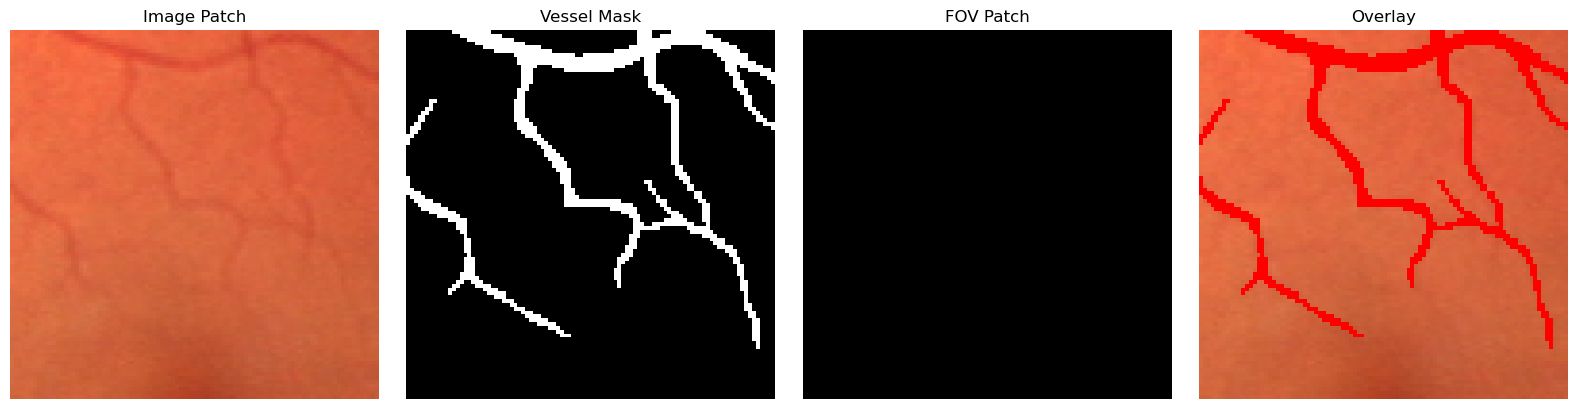

Saved figure: drive_transfer_figures/step5_drive_patch_example_1.png

Patch example 2
Image ID: 27
Location: y = 48 , x = 336
Vessel ratio: 0.0879
FOV ratio   : 0.9133


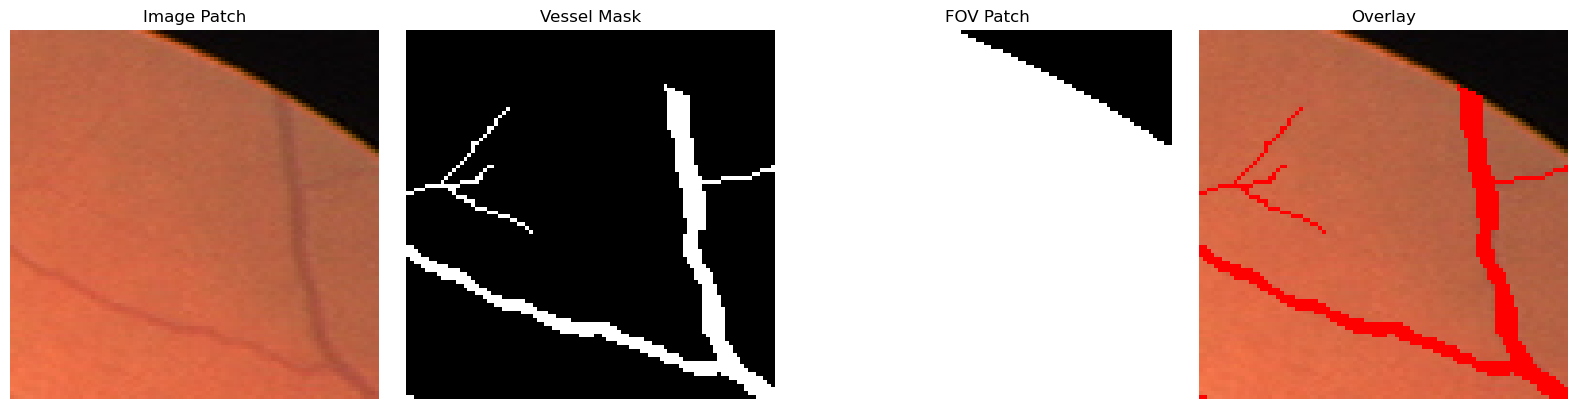

Saved figure: drive_transfer_figures/step5_drive_patch_example_2.png

Patch example 3
Image ID: 38
Location: y = 192 , x = 144
Vessel ratio: 0.0983
FOV ratio   : 1.0000


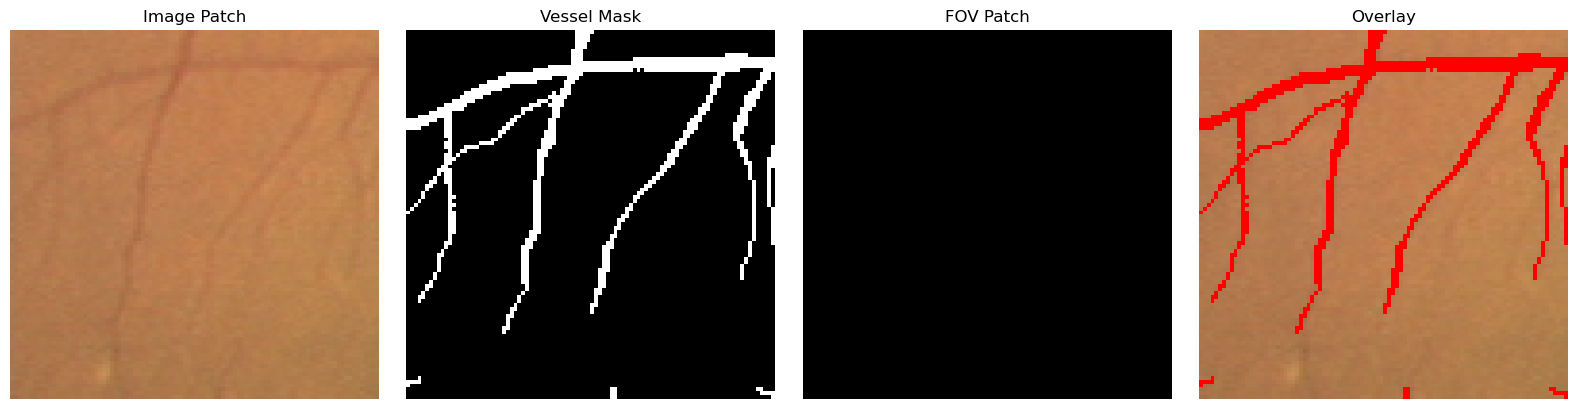

Saved figure: drive_transfer_figures/step5_drive_patch_example_3.png

Patch example 4
Image ID: 36
Location: y = 240 , x = 432
Vessel ratio: 0.3150
FOV ratio   : 1.0000


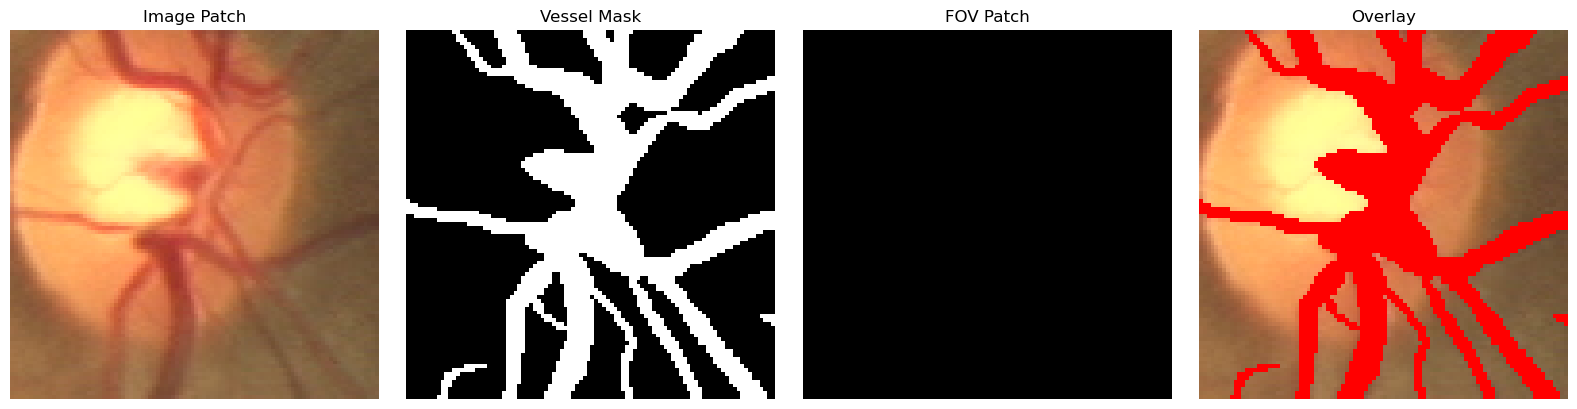

Saved figure: drive_transfer_figures/step5_drive_patch_example_4.png

Patch example 5
Image ID: 38
Location: y = 96 , x = 144
Vessel ratio: 0.1145
FOV ratio   : 1.0000


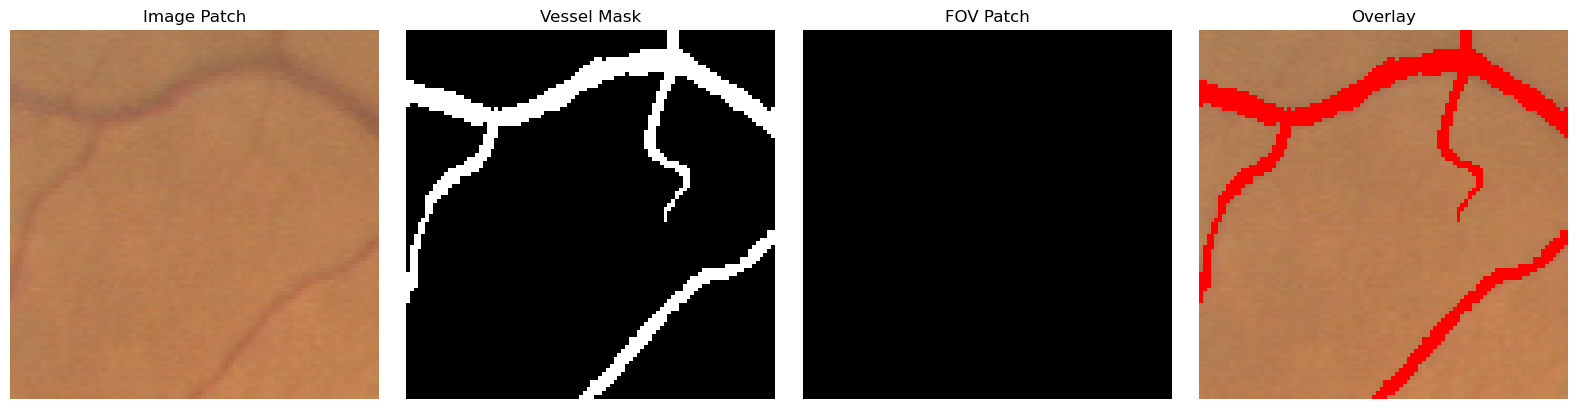

Saved figure: drive_transfer_figures/step5_drive_patch_example_5.png

Patch example 6
Image ID: 35
Location: y = 96 , x = 288
Vessel ratio: 0.1276
FOV ratio   : 1.0000


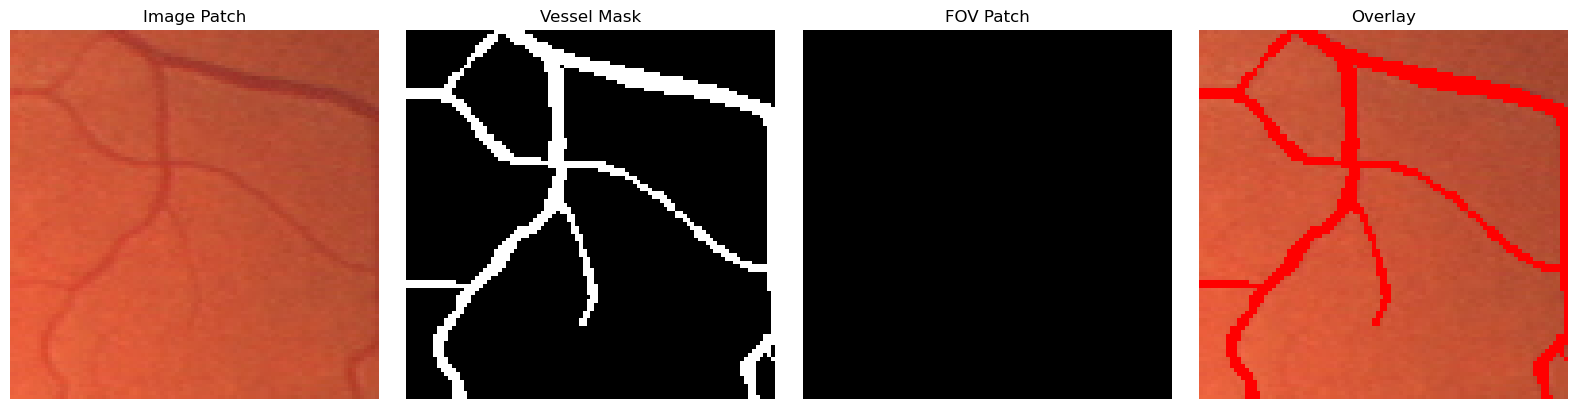

Saved figure: drive_transfer_figures/step5_drive_patch_example_6.png


In [5]:
# ============================================================
# STEP 5: Split DRIVE patches and visualize examples
# ============================================================
# This step splits DRIVE patches into training, validation, and test sets.
#
# Important:
# The split is done by image_id, not randomly by patch.
# This avoids data leakage because patches from the same retinal image
# should not appear in both training and testing.
#
# We also visualize selected vessel-rich patches to confirm that
# image patches and vessel masks are aligned.
# ============================================================

# ----------------------------
# Split by full retinal image ID
# ----------------------------
image_ids = sorted(
    list(set([p["image_id"] for p in drive_patches]))
)

random.seed(SEED)
random.shuffle(image_ids)

n_total = len(image_ids)
n_train = int(0.70 * n_total)
n_val = int(0.15 * n_total)

train_image_ids = set(image_ids[:n_train])
val_image_ids = set(image_ids[n_train:n_train + n_val])
test_image_ids = set(image_ids[n_train + n_val:])

train_patches = [
    p for p in drive_patches
    if p["image_id"] in train_image_ids
]

val_patches = [
    p for p in drive_patches
    if p["image_id"] in val_image_ids
]

test_patches = [
    p for p in drive_patches
    if p["image_id"] in test_image_ids
]

print("DRIVE image-level split")
print("-----------------------")
print("Total image IDs:", n_total)
print("Train image IDs:", len(train_image_ids), sorted(train_image_ids))
print("Val image IDs  :", len(val_image_ids), sorted(val_image_ids))
print("Test image IDs :", len(test_image_ids), sorted(test_image_ids))

print("\nPatch split")
print("-----------")
print("Train patches:", len(train_patches))
print("Val patches  :", len(val_patches))
print("Test patches :", len(test_patches))


# ----------------------------
# Split summary helper
# ----------------------------
def summarize_drive_split(patches, split_name):
    vessel_ratios = [
        p["vessel_ratio"]
        for p in patches
    ]

    fov_ratios = [
        p["fov_ratio"]
        for p in patches
    ]

    print(f"\n{split_name} summary")
    print("-" * 30)
    print("Number of patches:", len(patches))

    if len(patches) > 0:
        print(f"Mean vessel ratio: {np.mean(vessel_ratios):.4f}")
        print(f"Min vessel ratio : {np.min(vessel_ratios):.4f}")
        print(f"Max vessel ratio : {np.max(vessel_ratios):.4f}")
        print(f"Mean FOV ratio   : {np.mean(fov_ratios):.4f}")
        print(f"Min FOV ratio    : {np.min(fov_ratios):.4f}")
        print(f"Max FOV ratio    : {np.max(fov_ratios):.4f}")


summarize_drive_split(train_patches, "Train")
summarize_drive_split(val_patches, "Validation")
summarize_drive_split(test_patches, "Test")


# ============================================================
# Visualize selected vessel-rich patches
# ============================================================

vessel_indices = [
    i for i, p in enumerate(train_patches)
    if p["vessel_ratio"] >= 0.08
]

num_examples = min(6, len(vessel_indices))

if num_examples > 0:
    selected_indices = random.sample(
        vessel_indices,
        num_examples
    )
else:
    selected_indices = random.sample(
        range(len(train_patches)),
        min(6, len(train_patches))
    )

for count, idx in enumerate(selected_indices, start=1):
    patch = train_patches[idx]

    image_patch = patch["image_patch"]
    vessel_patch = patch["mask_patch"].astype(np.uint8)
    fov_patch = patch["fov_patch"].astype(np.uint8)

    overlay = image_patch.copy()
    overlay[vessel_patch == 1] = [1.0, 0.0, 0.0]

    print(f"\nPatch example {count}")
    print("Image ID:", patch["image_id"])
    print("Location: y =", patch["y"], ", x =", patch["x"])
    print(f"Vessel ratio: {patch['vessel_ratio']:.4f}")
    print(f"FOV ratio   : {patch['fov_ratio']:.4f}")

    plt.figure(figsize=(16, 4))

    plt.subplot(1, 4, 1)
    plt.imshow(image_patch)
    plt.title("Image Patch")
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(vessel_patch, cmap="gray")
    plt.title("Vessel Mask")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(fov_patch, cmap="gray")
    plt.title("FOV Patch")
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.imshow(overlay)
    plt.title("Overlay")
    plt.axis("off")

    plt.tight_layout()

    save_path = os.path.join(
        FIGURE_DIR,
        f"step5_drive_patch_example_{count}.png"
    )

    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved figure:", save_path)

In [6]:
# ============================================================
# STEP 6: Create DRIVE PyTorch datasets and dataloaders
# ============================================================
# This step converts DRIVE retinal image patches and vessel masks
# into PyTorch tensors.
#
# Image tensor shape:
#   [3, 96, 96]
#
# Mask tensor shape:
#   [1, 96, 96]
#
# The pretrained Road Model 5 also expects 3-channel input, so the
# DRIVE RGB patches can be used directly.
# ============================================================

class DRIVEPatchDataset(Dataset):
    def __init__(self, patches):
        self.patches = patches

    def __len__(self):
        return len(self.patches)

    def __getitem__(self, idx):
        patch = self.patches[idx]

        image_patch = patch["image_patch"].astype(np.float32)
        mask_patch = patch["mask_patch"].astype(np.float32)

        # Image: [H, W, 3] -> [3, H, W]
        image_tensor = torch.from_numpy(image_patch).permute(2, 0, 1)

        # Mask: [H, W] -> [1, H, W]
        mask_tensor = torch.from_numpy(mask_patch).unsqueeze(0)

        return image_tensor, mask_tensor


# ----------------------------
# Create dataset objects
# ----------------------------
train_dataset = DRIVEPatchDataset(train_patches)
val_dataset = DRIVEPatchDataset(val_patches)
test_dataset = DRIVEPatchDataset(test_patches)


# ----------------------------
# Create dataloaders
# ----------------------------
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)


# ----------------------------
# Check one batch
# ----------------------------
images, masks = next(iter(train_loader))

print("Train dataset size     :", len(train_dataset))
print("Validation dataset size:", len(val_dataset))
print("Test dataset size      :", len(test_dataset))

print("\nTrain batches     :", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches      :", len(test_loader))

print("\nImage batch shape:", images.shape)
print("Mask batch shape :", masks.shape)

print("\nImage min:", images.min().item())
print("Image max:", images.max().item())
print("Mask unique values:", torch.unique(masks))
print("Batch vessel ratio:", masks.mean().item())

Train dataset size     : 1301
Validation dataset size: 278
Test dataset size      : 280

Train batches     : 163
Validation batches: 35
Test batches      : 35

Image batch shape: torch.Size([8, 3, 96, 96])
Mask batch shape : torch.Size([8, 1, 96, 96])

Image min: 0.0
Image max: 1.0
Mask unique values: tensor([0., 1.])
Batch vessel ratio: 0.1344943642616272


In [7]:
# ============================================================
# STEP 7: Define U-Net and load pretrained Road Model 5
# ============================================================
# This step prepares the transfer-learning model for DRIVE.
#
# Source model:
#   Road Model 5:
#   BCE + Dice + soft-clDice + SATLoss Creator
#
# Target task:
#   Retinal vessel segmentation
#
# DRIVE images are RGB, so their input shape already matches the road model:
#   [B, 3, 96, 96]
# ============================================================

# ----------------------------
# U-Net building block
# ----------------------------
class DoubleConv(nn.Module):
    """
    Two convolution layers with BatchNorm and ReLU.
    """

    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.double_conv = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)


# ----------------------------
# U-Net model
# ----------------------------
class UNet(nn.Module):
    """
    U-Net segmentation model.

    This architecture must match the road model architecture exactly,
    otherwise pretrained weights cannot be loaded.
    """

    def __init__(self, in_channels=3, out_channels=1):
        super().__init__()

        self.down1 = DoubleConv(in_channels, 64)
        self.pool1 = nn.MaxPool2d(kernel_size=2)

        self.down2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(kernel_size=2)

        self.down3 = DoubleConv(128, 256)
        self.pool3 = nn.MaxPool2d(kernel_size=2)

        self.down4 = DoubleConv(256, 512)
        self.pool4 = nn.MaxPool2d(kernel_size=2)

        self.bottleneck = DoubleConv(512, 1024)

        self.up4 = nn.ConvTranspose2d(
            1024,
            512,
            kernel_size=2,
            stride=2
        )
        self.conv4 = DoubleConv(1024, 512)

        self.up3 = nn.ConvTranspose2d(
            512,
            256,
            kernel_size=2,
            stride=2
        )
        self.conv3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(
            256,
            128,
            kernel_size=2,
            stride=2
        )
        self.conv2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(
            128,
            64,
            kernel_size=2,
            stride=2
        )
        self.conv1 = DoubleConv(128, 64)

        self.final_conv = nn.Conv2d(
            64,
            out_channels,
            kernel_size=1
        )

    def forward(self, x):
        c1 = self.down1(x)
        p1 = self.pool1(c1)

        c2 = self.down2(p1)
        p2 = self.pool2(c2)

        c3 = self.down3(p2)
        p3 = self.pool3(c3)

        c4 = self.down4(p3)
        p4 = self.pool4(c4)

        bn = self.bottleneck(p4)

        u4 = self.up4(bn)
        u4 = torch.cat([u4, c4], dim=1)
        c5 = self.conv4(u4)

        u3 = self.up3(c5)
        u3 = torch.cat([u3, c3], dim=1)
        c6 = self.conv3(u3)

        u2 = self.up2(c6)
        u2 = torch.cat([u2, c2], dim=1)
        c7 = self.conv2(u2)

        u1 = self.up1(c7)
        u1 = torch.cat([u1, c1], dim=1)
        c8 = self.conv1(u1)

        logits = self.final_conv(c8)

        return logits


# ----------------------------
# Create DRIVE transfer model
# ----------------------------
drive_model = UNet(
    in_channels=3,
    out_channels=1
).to(device)


# ----------------------------
# Confirm pretrained Road Model 5 path
# ----------------------------
PRETRAINED_ROAD_MODEL_PATH = (
    "/home/mutie/final_thesis_models/"
    "best_hybrid_sat_creator_model.pth"
)

if not os.path.exists(PRETRAINED_ROAD_MODEL_PATH):
    raise FileNotFoundError(
        f"Pretrained Road Model 5 not found: {PRETRAINED_ROAD_MODEL_PATH}"
    )

print("Loading pretrained Road Model 5 from:")
print(PRETRAINED_ROAD_MODEL_PATH)


# ----------------------------
# Load pretrained weights
# ----------------------------
pretrained_state = torch.load(
    PRETRAINED_ROAD_MODEL_PATH,
    map_location=device
)

missing_keys, unexpected_keys = drive_model.load_state_dict(
    pretrained_state,
    strict=False
)

print("\nPretrained Road Model 5 loaded successfully.")
print("Missing keys:", missing_keys)
print("Unexpected keys:", unexpected_keys)


# ----------------------------
# Test one forward pass
# ----------------------------
images, masks = next(iter(train_loader))
images = images.to(device)
masks = masks.to(device)

drive_model.eval()

with torch.no_grad():
    logits = drive_model(images)

print("\nForward pass test")
print("-----------------")
print("Input image shape :", images.shape)
print("Output logits shape:", logits.shape)
print("Expected mask shape:", masks.shape)

assert logits.shape == masks.shape, "Output shape does not match mask shape."

num_params = sum(
    p.numel()
    for p in drive_model.parameters()
    if p.requires_grad
)

print("Trainable parameters:", num_params)

Loading pretrained Road Model 5 from:
/home/mutie/final_thesis_models/best_hybrid_sat_creator_model.pth

Pretrained Road Model 5 loaded successfully.
Missing keys: []
Unexpected keys: []

Forward pass test
-----------------
Input image shape : torch.Size([8, 3, 96, 96])
Output logits shape: torch.Size([8, 1, 96, 96])
Expected mask shape: torch.Size([8, 1, 96, 96])
Trainable parameters: 31037633


In [8]:
# ============================================================
# STEP 8: Define losses and evaluation metrics for DRIVE
# ============================================================
# This step defines the training losses and evaluation metrics for
# retinal vessel segmentation.
#
# Training loss:
#   BCE + Dice loss + soft-clDice loss
#
# Evaluation metrics:
#   Accuracy
#   Dice
#   clDice
#   beta0 error
#   beta1 error
#
# beta0 measures connected components.
# beta1 measures holes/loops.
# ============================================================

# ----------------------------
# BCE loss
# ----------------------------
bce_loss_fn = nn.BCEWithLogitsLoss()


# ----------------------------
# Dice loss and Dice score
# ----------------------------
def dice_loss(probs, targets, eps=1e-8):
    probs = probs.float()
    targets = targets.float()

    intersection = (probs * targets).sum(dim=(1, 2, 3))
    union = probs.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3))

    dice = (2.0 * intersection + eps) / (union + eps)

    return 1.0 - dice.mean()


def dice_score(preds, targets, eps=1e-8):
    preds = preds.float()
    targets = targets.float()

    intersection = (preds * targets).sum()
    union = preds.sum() + targets.sum()

    dice = (2.0 * intersection + eps) / (union + eps)

    return dice.item()


# ----------------------------
# Pixel accuracy
# ----------------------------
def accuracy_score(preds, targets):
    correct = (preds == targets).float().sum()
    total = torch.numel(targets)

    return (correct / total).item()


# ----------------------------
# soft-clDice loss
# ----------------------------
CLDICE_ITERATIONS = 3

def soft_erode(img):
    p1 = -F.max_pool2d(
        -img,
        kernel_size=(3, 1),
        stride=1,
        padding=(1, 0)
    )

    p2 = -F.max_pool2d(
        -img,
        kernel_size=(1, 3),
        stride=1,
        padding=(0, 1)
    )

    return torch.min(p1, p2)


def soft_dilate(img):
    return F.max_pool2d(
        img,
        kernel_size=3,
        stride=1,
        padding=1
    )


def soft_open(img):
    return soft_dilate(soft_erode(img))


def soft_skeletonize(img, iterations=3):
    img = img.float()

    opened = soft_open(img)
    skeleton = F.relu(img - opened)

    for _ in range(iterations):
        img = soft_erode(img)
        opened = soft_open(img)

        delta = F.relu(img - opened)
        skeleton = skeleton + F.relu(delta - skeleton * delta)

    return skeleton


def soft_cldice_loss(probs, targets, iterations=3, eps=1e-8):
    probs = probs.float()
    targets = targets.float()

    skel_pred = soft_skeletonize(
        probs,
        iterations=iterations
    )

    skel_true = soft_skeletonize(
        targets,
        iterations=iterations
    )

    tprec = (skel_pred * targets).sum(dim=(1, 2, 3)) / (
        skel_pred.sum(dim=(1, 2, 3)) + eps
    )

    tsens = (skel_true * probs).sum(dim=(1, 2, 3)) / (
        skel_true.sum(dim=(1, 2, 3)) + eps
    )

    cldice = (2.0 * tprec * tsens + eps) / (
        tprec + tsens + eps
    )

    return 1.0 - cldice.mean()


# ----------------------------
# clDice score for evaluation
# ----------------------------
def cldice_score(pred_np, target_np, eps=1e-8):
    pred_np = pred_np.astype(bool)
    target_np = target_np.astype(bool)

    skel_pred = skeletonize(pred_np)
    skel_target = skeletonize(target_np)

    if skel_pred.sum() == 0 and skel_target.sum() == 0:
        return 1.0

    if skel_pred.sum() == 0 or skel_target.sum() == 0:
        return 0.0

    tprec = (skel_pred * target_np).sum() / (
        skel_pred.sum() + eps
    )

    tsens = (skel_target * pred_np).sum() / (
        skel_target.sum() + eps
    )

    return float(
        (2.0 * tprec * tsens) / (tprec + tsens + eps)
    )


# ----------------------------
# Betti numbers
# ----------------------------
def betti_numbers(binary_np):
    binary_np = binary_np.astype(bool)

    labeled_fg = label(binary_np, connectivity=2)
    beta0 = labeled_fg.max()

    filled = binary_fill_holes(binary_np)
    holes = filled & (~binary_np)

    labeled_holes = label(holes, connectivity=2)
    beta1 = labeled_holes.max()

    return beta0, beta1


def betti_error(pred_np, target_np):
    b0_pred, b1_pred = betti_numbers(pred_np)
    b0_true, b1_true = betti_numbers(target_np)

    return abs(b0_pred - b0_true), abs(b1_pred - b1_true)


# ----------------------------
# Evaluation function
# ----------------------------
def evaluate_drive_model(model, loader, device, threshold=0.5):
    model.eval()

    loss_values = []
    acc_values = []
    dice_values = []
    cldice_values = []
    beta0_values = []
    beta1_values = []

    with torch.no_grad():
        for images, masks in tqdm(loader, desc="Evaluating DRIVE"):
            images = images.to(device)
            masks = masks.to(device)

            logits = model(images)
            probs = torch.sigmoid(logits)
            preds = (probs > threshold).float()

            bce = bce_loss_fn(logits, masks)
            dloss = dice_loss(probs, masks)
            closs = soft_cldice_loss(
                probs,
                masks,
                iterations=CLDICE_ITERATIONS
            )

            loss = bce + dloss + closs

            loss_values.append(loss.item())
            acc_values.append(accuracy_score(preds.cpu(), masks.cpu()))
            dice_values.append(dice_score(preds.cpu(), masks.cpu()))

            for i in range(images.shape[0]):
                pred_np = preds[i, 0].cpu().numpy().astype(np.uint8)
                mask_np = masks[i, 0].cpu().numpy().astype(np.uint8)

                cldice_values.append(
                    cldice_score(pred_np, mask_np)
                )

                b0_err, b1_err = betti_error(pred_np, mask_np)
                beta0_values.append(b0_err)
                beta1_values.append(b1_err)

    return {
        "loss": float(np.mean(loss_values)),
        "accuracy": float(np.mean(acc_values)),
        "dice": float(np.mean(dice_values)),
        "cldice": float(np.mean(cldice_values)),
        "beta0_error": float(np.mean(beta0_values)),
        "beta1_error": float(np.mean(beta1_values)),
        "threshold": threshold
    }


# ----------------------------
# Quick test before DRIVE fine-tuning
# ----------------------------
drive_model.eval()

images, masks = next(iter(train_loader))
images = images.to(device)
masks = masks.to(device)

with torch.no_grad():
    logits = drive_model(images)
    probs = torch.sigmoid(logits)
    preds = (probs > 0.5).float()

print("Quick metric test before DRIVE fine-tuning")
print("------------------------------------------")
print("BCE loss:", bce_loss_fn(logits, masks).item())
print("Dice loss:", dice_loss(probs, masks).item())
print("soft-clDice loss:", soft_cldice_loss(probs, masks).item())
print("Accuracy:", accuracy_score(preds.cpu(), masks.cpu()))
print("Dice:", dice_score(preds.cpu(), masks.cpu()))

Quick metric test before DRIVE fine-tuning
------------------------------------------
BCE loss: 1.1886751651763916
Dice loss: 0.9996048212051392
soft-clDice loss: 0.9995802640914917
Accuracy: 0.8645155429840088
Dice: 1.0011012201507907e-12


In [9]:
# ============================================================
# STEP 9: Fine-tune pretrained Road Model 5 on DRIVE retina dataset
# ============================================================
# This step fine-tunes the pretrained topology-aware road model
# on retinal vessel segmentation.
#
# Starting model:
#   Road Model 5 = BCE + Dice + soft-clDice + SATLoss Creator
#
# Fine-tuning loss:
#   L = BCE + Dice loss + soft-clDice loss
#
# Why no SATLoss yet?
#   We first allow the pretrained model to adapt to retinal vessel appearance.
#   SATLoss can be added later as a topology refinement stage.
# ============================================================

DRIVE_EPOCHS = 30
DRIVE_LR = 1e-4
DRIVE_WEIGHT_DECAY = 1e-4

drive_optimizer = optim.Adam(
    drive_model.parameters(),
    lr=DRIVE_LR,
    weight_decay=DRIVE_WEIGHT_DECAY
)

drive_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    drive_optimizer,
    mode="max",
    factor=0.5,
    patience=4
)

scaler = torch.cuda.amp.GradScaler()

drive_history = {
    "train_total_loss": [],
    "train_bce_loss": [],
    "train_dice_loss": [],
    "train_cldice_loss": [],
    "val_loss": [],
    "val_accuracy": [],
    "val_dice": [],
    "val_cldice": [],
    "val_beta0_error": [],
    "val_beta1_error": []
}


def train_one_epoch_drive(
    model,
    loader,
    optimizer,
    scaler,
    device
):
    """
    Train one epoch using:
        BCE + Dice + soft-clDice
    """

    model.train()

    total_loss = 0.0
    total_bce = 0.0
    total_dice = 0.0
    total_cldice = 0.0

    for images, masks in tqdm(loader, desc="Training DRIVE"):
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            logits = model(images)
            probs = torch.sigmoid(logits)

            bce = bce_loss_fn(logits, masks)
            dloss = dice_loss(probs, masks)

        closs = soft_cldice_loss(
            probs.float(),
            masks.float(),
            iterations=CLDICE_ITERATIONS
        )

        loss = bce + dloss + closs

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        total_bce += bce.item()
        total_dice += dloss.item()
        total_cldice += closs.item()

    return {
        "loss": total_loss / len(loader),
        "bce": total_bce / len(loader),
        "dice": total_dice / len(loader),
        "cldice": total_cldice / len(loader)
    }


best_drive_dice = -1.0
best_drive_state = None

for epoch in range(DRIVE_EPOCHS):

    print(f"\nDRIVE Fine-tuning Epoch {epoch + 1}/{DRIVE_EPOCHS}")
    print("-" * 60)

    train_metrics = train_one_epoch_drive(
        drive_model,
        train_loader,
        drive_optimizer,
        scaler,
        device
    )

    val_metrics = evaluate_drive_model(
        drive_model,
        val_loader,
        device,
        threshold=0.5
    )

    drive_scheduler.step(val_metrics["dice"])

    drive_history["train_total_loss"].append(train_metrics["loss"])
    drive_history["train_bce_loss"].append(train_metrics["bce"])
    drive_history["train_dice_loss"].append(train_metrics["dice"])
    drive_history["train_cldice_loss"].append(train_metrics["cldice"])

    drive_history["val_loss"].append(val_metrics["loss"])
    drive_history["val_accuracy"].append(val_metrics["accuracy"])
    drive_history["val_dice"].append(val_metrics["dice"])
    drive_history["val_cldice"].append(val_metrics["cldice"])
    drive_history["val_beta0_error"].append(val_metrics["beta0_error"])
    drive_history["val_beta1_error"].append(val_metrics["beta1_error"])

    print(f"Train Total Loss : {train_metrics['loss']:.4f}")
    print(f"Train BCE Loss   : {train_metrics['bce']:.4f}")
    print(f"Train Dice Loss  : {train_metrics['dice']:.4f}")
    print(f"Train clDice Loss: {train_metrics['cldice']:.4f}")

    print(f"Val Loss         : {val_metrics['loss']:.4f}")
    print(f"Val Accuracy     : {val_metrics['accuracy']:.4f}")
    print(f"Val Dice         : {val_metrics['dice']:.4f}")
    print(f"Val clDice       : {val_metrics['cldice']:.4f}")
    print(f"Val beta0 err    : {val_metrics['beta0_error']:.4f}")
    print(f"Val beta1 err    : {val_metrics['beta1_error']:.4f}")

    current_lr = drive_optimizer.param_groups[0]["lr"]
    print(f"Learning rate    : {current_lr:.6f}")

    if val_metrics["dice"] > best_drive_dice:

        best_drive_dice = val_metrics["dice"]
        best_drive_state = copy.deepcopy(
            drive_model.state_dict()
        )

        torch.save(
            best_drive_state,
            os.path.join(
                SAVE_DIR,
                "best_drive_transfer_model.pth"
            )
        )

        print("Best DRIVE transfer model saved.")

print("\nDRIVE fine-tuning finished.")
print("Best validation Dice:", best_drive_dice)


DRIVE Fine-tuning Epoch 1/30
------------------------------------------------------------


Evaluating DRIVE: 100%|██████████| 35/35 [00:03<00:00, 10.60it/s]


Train Total Loss : 1.0518
Train BCE Loss   : 0.2528
Train Dice Loss  : 0.4282
Train clDice Loss: 0.3708
Val Loss         : 0.8870
Val Accuracy     : 0.9224
Val Dice         : 0.6941
Val clDice       : 0.7190
Val beta0 err    : 4.0036
Val beta1 err    : 0.8993
Learning rate    : 0.000100
Best DRIVE transfer model saved.

DRIVE Fine-tuning Epoch 2/30
------------------------------------------------------------


Evaluating DRIVE: 100%|██████████| 35/35 [00:03<00:00, 10.87it/s]


Train Total Loss : 0.7286
Train BCE Loss   : 0.1737
Train Dice Loss  : 0.3031
Train clDice Loss: 0.2519
Val Loss         : 0.7764
Val Accuracy     : 0.9361
Val Dice         : 0.7284
Val clDice       : 0.7494
Val beta0 err    : 4.5432
Val beta1 err    : 0.7662
Learning rate    : 0.000100
Best DRIVE transfer model saved.

DRIVE Fine-tuning Epoch 3/30
------------------------------------------------------------


...

Train Total Loss : 0.2979
Train BCE Loss   : 0.0744
Train Dice Loss  : 0.1353
Train clDice Loss: 0.0882
Val Loss         : 0.7087
Val Accuracy     : 0.9489
Val Dice         : 0.7663
Val clDice       : 0.7699
Val beta0 err    : 3.5324
Val beta1 err    : 0.6619
Learning rate    : 0.000006

DRIVE Fine-tuning Epoch 29/30
------------------------------------------------------------


Evaluating DRIVE: 100%|██████████| 35/35 [00:02<00:00, 12.71it/s]


Train Total Loss : 0.2990
Train BCE Loss   : 0.0752
Train Dice Loss  : 0.1354
Train clDice Loss: 0.0885
Val Loss         : 0.7121
Val Accuracy     : 0.9495
Val Dice         : 0.7642
Val clDice       : 0.7685
Val beta0 err    : 3.5360
Val beta1 err    : 0.6367
Learning rate    : 0.000006

DRIVE Fine-tuning Epoch 30/30
------------------------------------------------------------


Evaluating DRIVE: 100%|██████████| 35/35 [00:03<00:00, 10.73it/s]

Train Total Loss : 0.2950
Train BCE Loss   : 0.0738
Train Dice Loss  : 0.1333
Train clDice Loss: 0.0879
Val Loss         : 0.7093
Val Accuracy     : 0.9495
Val Dice         : 0.7662
Val clDice       : 0.7692
Val beta0 err    : 3.4532
Val beta1 err    : 0.6655
Learning rate    : 0.000006

DRIVE fine-tuning finished.
Best validation Dice: 0.7776360494749887


In [10]:
# ============================================================
# STEP 10: Final evaluation of DRIVE transfer model
# ============================================================
# This step evaluates the best saved DRIVE transfer-learning model
# on the DRIVE test patches.
#
# Model:
#   Road Model 5 transferred to retinal vessel segmentation
#
# Training loss:
#   BCE + Dice + soft-clDice
#
# The best checkpoint was selected using validation Dice.
# ============================================================

# ----------------------------
# Load best DRIVE transfer model
# ----------------------------
final_drive_model = UNet(
    in_channels=3,
    out_channels=1
).to(device)

final_drive_model.load_state_dict(
    torch.load(
        os.path.join(SAVE_DIR, "best_drive_transfer_model.pth"),
        map_location=device
    )
)

final_drive_model.eval()


# ----------------------------
# Evaluate on test set
# ----------------------------
drive_test_metrics = evaluate_drive_model(
    final_drive_model,
    test_loader,
    device,
    threshold=0.5
)


# ----------------------------
# Print final test results
# ----------------------------
print("FINAL TEST RESULTS: DRIVE Transfer Learning")
print("-------------------------------------------")
print(f"Test Loss       : {drive_test_metrics['loss']:.4f}")
print(f"Test Accuracy   : {drive_test_metrics['accuracy']:.4f}")
print(f"Test Dice       : {drive_test_metrics['dice']:.4f}")
print(f"Test clDice     : {drive_test_metrics['cldice']:.4f}")
print(f"Test beta0 err  : {drive_test_metrics['beta0_error']:.4f}")
print(f"Test beta1 err  : {drive_test_metrics['beta1_error']:.4f}")
print(f"Threshold       : {drive_test_metrics['threshold']:.4f}")


# ----------------------------
# Save final test results
# ----------------------------
drive_result = {
    "Model": "Road Model 5 Transfer to DRIVE",
    "Loss": drive_test_metrics["loss"],
    "Accuracy": drive_test_metrics["accuracy"],
    "Dice": drive_test_metrics["dice"],
    "clDice": drive_test_metrics["cldice"],
    "beta0_error": drive_test_metrics["beta0_error"],
    "beta1_error": drive_test_metrics["beta1_error"],
    "Threshold": drive_test_metrics["threshold"]
}

drive_results_df = pd.DataFrame([drive_result])

drive_results_path = os.path.join(
    RESULTS_DIR,
    "drive_transfer_test_results.csv"
)

drive_results_df.to_csv(
    drive_results_path,
    index=False
)

print("\nSaved DRIVE test results to:")
print(drive_results_path)

Evaluating DRIVE: 100%|██████████| 35/35 [00:02<00:00, 11.98it/s]

FINAL TEST RESULTS: DRIVE Transfer Learning
-------------------------------------------
Test Loss       : 0.6549
Test Accuracy   : 0.9518
Test Dice       : 0.7976
Test clDice     : 0.7828
Test beta0 err  : 1.4179
Test beta1 err  : 0.7107
Threshold       : 0.5000

Saved DRIVE test results to:
drive_transfer_results/drive_transfer_test_results.csv


Selected test patch indices: [156, 98, 164, 209, 114, 3, 275, 76]

Patch 1
Image ID: 24
Location: y = 336 , x = 144
Ground-truth vessel ratio: 12.88%
Predicted vessel ratio   : 11.76%

Patch 2
Image ID: 24
Location: y = 48 , x = 144
Ground-truth vessel ratio: 21.72%
Predicted vessel ratio   : 17.74%

Patch 3
Image ID: 24
Location: y = 384 , x = 48
Ground-truth vessel ratio: 13.75%
Predicted vessel ratio   : 11.59%

Patch 4
Image ID: 29
Location: y = 144 , x = 144
Ground-truth vessel ratio: 11.98%
Predicted vessel ratio   : 12.45%

Patch 5
Image ID: 24
Location: y = 144 , x = 48
Ground-truth vessel ratio: 9.52%
Predicted vessel ratio   : 7.60%

Patch 6
Image ID: 21
Location: y = 48 , x = 96
Ground-truth vessel ratio: 10.20%
Predicted vessel ratio   : 10.07%

Patch 7
Image ID: 29
Location: y = 480 , x = 144
Ground-truth vessel ratio: 8.50%
Predicted vessel ratio   : 7.69%

Patch 8
Image ID: 21
Location: y = 384 , x = 336
Ground-truth vessel ratio: 11.69%
Predicted vessel ratio   : 12.67%

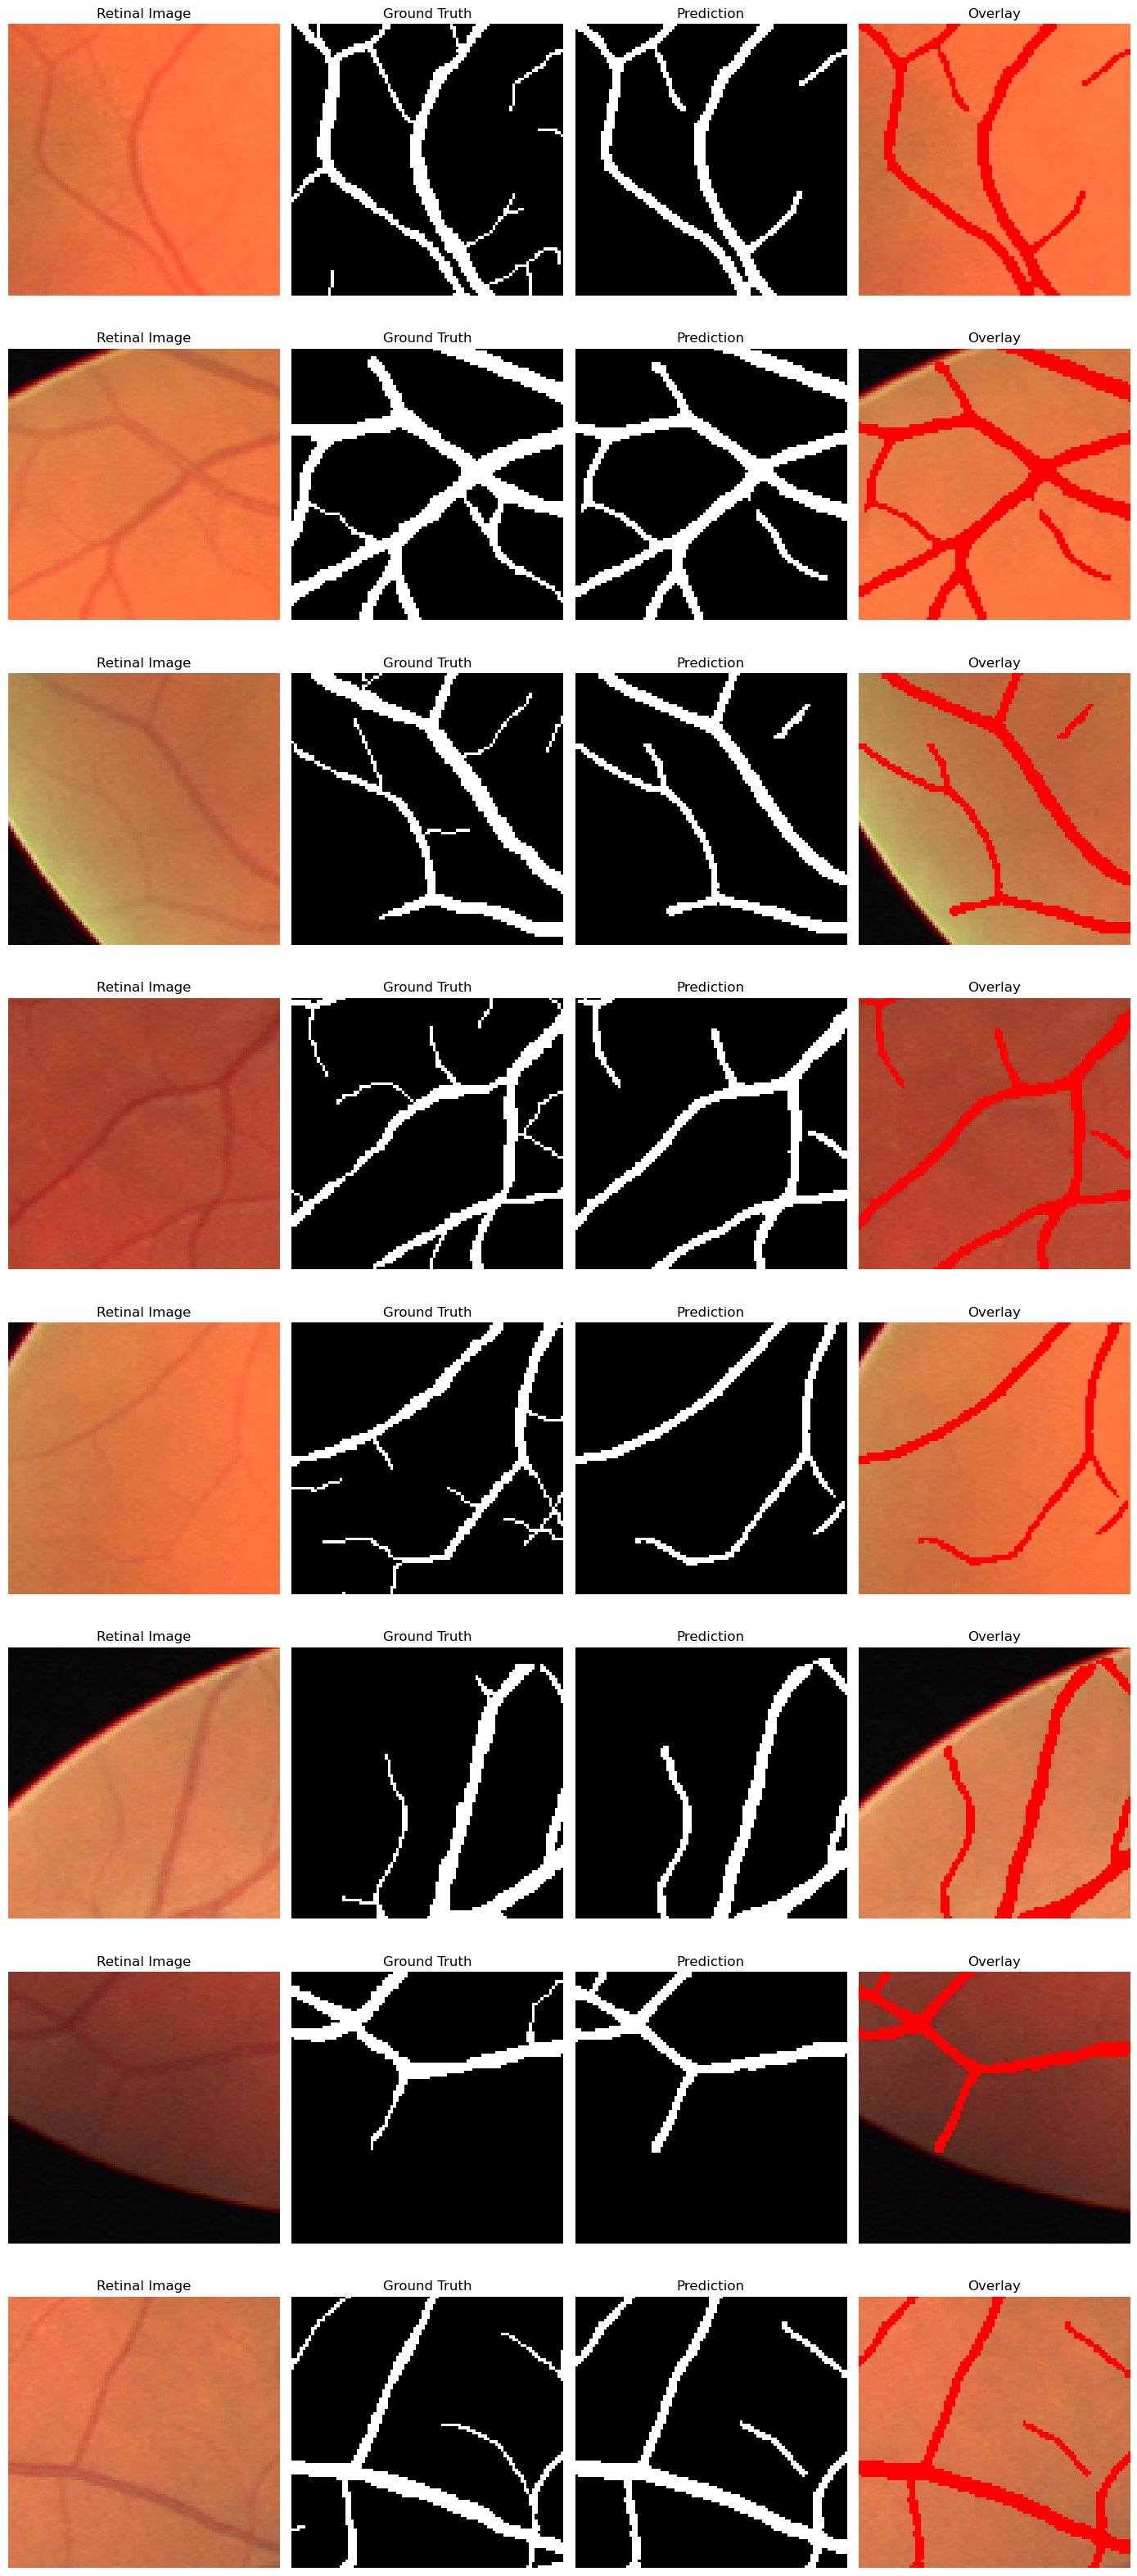


Saved DRIVE prediction visualization to:
drive_transfer_figures/step11_drive_transfer_test_predictions.png


In [11]:
# ============================================================
# STEP 11: Visualize DRIVE test predictions
# ============================================================
# This step visualizes predictions from the final DRIVE transfer model.
#
# Columns:
#   Image | Ground Truth | Prediction | Overlay
#
# Red overlay = predicted retinal vessels.
# ============================================================

final_drive_model.eval()

# ----------------------------
# Select vessel-rich test patches
# ----------------------------
vessel_indices = [
    i for i, p in enumerate(test_patches)
    if p["vessel_ratio"] >= 0.08
]

num_samples = 8

selected_indices = random.sample(
    vessel_indices,
    min(num_samples, len(vessel_indices))
)

print("Selected test patch indices:", selected_indices)


# ----------------------------
# Visualize predictions
# ----------------------------
plt.figure(figsize=(14, 4 * len(selected_indices)))

for row, idx in enumerate(selected_indices):
    patch = test_patches[idx]

    image_patch = patch["image_patch"]
    mask_patch = patch["mask_patch"]

    image_tensor = torch.from_numpy(
        image_patch.astype(np.float32)
    ).permute(2, 0, 1).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = final_drive_model(image_tensor)
        probs = torch.sigmoid(logits)
        pred = (probs > 0.5).float()

    pred_np = pred[0, 0].cpu().numpy().astype(np.uint8)
    mask_np = mask_patch.astype(np.uint8)
    image_display = image_patch.astype(np.float32)

    overlay = image_display.copy()
    overlay[pred_np == 1] = [1.0, 0.0, 0.0]

    print(f"\nPatch {row + 1}")
    print("Image ID:", patch["image_id"])
    print("Location: y =", patch["y"], ", x =", patch["x"])
    print(f"Ground-truth vessel ratio: {patch['vessel_ratio'] * 100:.2f}%")
    print(f"Predicted vessel ratio   : {pred_np.mean() * 100:.2f}%")

    plt.subplot(len(selected_indices), 4, 4 * row + 1)
    plt.imshow(image_display)
    plt.title("Retinal Image")
    plt.axis("off")

    plt.subplot(len(selected_indices), 4, 4 * row + 2)
    plt.imshow(mask_np, cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(len(selected_indices), 4, 4 * row + 3)
    plt.imshow(pred_np, cmap="gray")
    plt.title("Prediction")
    plt.axis("off")

    plt.subplot(len(selected_indices), 4, 4 * row + 4)
    plt.imshow(overlay)
    plt.title("Overlay")
    plt.axis("off")

plt.tight_layout()

save_path = os.path.join(
    FIGURE_DIR,
    "step11_drive_transfer_test_predictions.png"
)

plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("\nSaved DRIVE prediction visualization to:")
print(save_path)

# Define SATLoss Creator for DRIVE

In [13]:
# ============================================================
# STEP 12A: Define SATLoss Creator for DRIVE
# ============================================================

SPATIAL_MIN_WEIGHT = 0.05


def flat_to_xy(index, width):
    y = index // width
    x = index % width
    return int(y), int(x)


def get_persistence_features_2d(prob_np, max_features=20):
    H, W = prob_np.shape
    prob_np = prob_np.astype(np.float64)

    cubical_complex = gudhi.CubicalComplex(
        top_dimensional_cells=-prob_np
    )

    cubical_complex.persistence()
    pairs, _ = cubical_complex.cofaces_of_persistence_pairs()

    features = []

    for dim in [0, 1]:
        if dim >= len(pairs):
            continue

        for pair in pairs[dim]:
            if len(pair) < 2:
                continue

            birth_idx = int(pair[0])
            death_idx = int(pair[1])

            by, bx = flat_to_xy(birth_idx, W)
            dy, dx = flat_to_xy(death_idx, W)

            if not (0 <= by < H and 0 <= bx < W):
                continue

            if not (0 <= dy < H and 0 <= dx < W):
                continue

            birth_value = float(prob_np[by, bx])
            death_value = float(prob_np[dy, dx])
            persistence = abs(birth_value - death_value)

            features.append({
                "dim": dim,
                "birth_xy": (by, bx),
                "death_xy": (dy, dx),
                "birth": birth_value,
                "death": death_value,
                "persistence": persistence
            })

    features = sorted(
        features,
        key=lambda item: item["persistence"],
        reverse=True
    )

    return features[:max_features]


def spatial_aware_cost(pred_feature, true_feature, H, W):
    by, bx = pred_feature["birth_xy"]
    tby, tbx = true_feature["birth_xy"]

    spatial_dist = (
        ((by / H) - (tby / H)) ** 2
        + ((bx / W) - (tbx / W)) ** 2
    )

    spatial_weight = max(spatial_dist, SPATIAL_MIN_WEIGHT)

    diagram_cost = (
        (pred_feature["birth"] - true_feature["birth"]) ** 2
        + (pred_feature["death"] - true_feature["death"]) ** 2
    )

    return spatial_weight * diagram_cost


def match_features_greedy(pred_features, true_features, H, W):
    matched_pairs = []
    used_true_indices = set()

    for pred_feature in pred_features:
        best_cost = None
        best_index = None

        for j, true_feature in enumerate(true_features):
            if j in used_true_indices:
                continue

            if pred_feature["dim"] != true_feature["dim"]:
                continue

            cost = spatial_aware_cost(
                pred_feature,
                true_feature,
                H,
                W
            )

            if best_cost is None or cost < best_cost:
                best_cost = cost
                best_index = j

        if best_index is not None:
            matched_pairs.append(
                (pred_feature, true_features[best_index])
            )
            used_true_indices.add(best_index)

    return matched_pairs


def creator_loss_from_matches(prob_tensor, matched_pairs, H, W):
    device = prob_tensor.device
    total_loss = torch.tensor(0.0, device=device)

    if len(matched_pairs) == 0:
        return total_loss

    for pred_feature, true_feature in matched_pairs:
        by, bx = pred_feature["birth_xy"]
        dy, dx = pred_feature["death_xy"]

        pred_birth = prob_tensor[by, bx]
        pred_death = prob_tensor[dy, dx]

        true_birth = torch.tensor(
            true_feature["birth"],
            device=device,
            dtype=prob_tensor.dtype
        )

        true_death = torch.tensor(
            true_feature["death"],
            device=device,
            dtype=prob_tensor.dtype
        )

        spatial_weight = spatial_aware_cost(
            pred_feature,
            true_feature,
            H,
            W
        )

        total_loss = total_loss + spatial_weight * (
            (pred_birth - true_birth) ** 2
            + (pred_death - true_death) ** 2
        )

    return total_loss / len(matched_pairs)


def satloss_single(prob_tensor, mask_tensor, max_features=20):
    H, W = prob_tensor.shape
    device = prob_tensor.device

    prob_np = prob_tensor.detach().cpu().numpy()
    mask_np = mask_tensor.detach().cpu().numpy()

    pred_features = get_persistence_features_2d(
        prob_np,
        max_features=max_features
    )

    true_features = get_persistence_features_2d(
        mask_np,
        max_features=max_features
    )

    if len(pred_features) == 0 or len(true_features) == 0:
        return torch.tensor(0.0, device=device)

    matched_pairs = match_features_greedy(
        pred_features,
        true_features,
        H,
        W
    )

    return creator_loss_from_matches(
        prob_tensor,
        matched_pairs,
        H,
        W
    )


def satloss_batch(
    probs,
    masks,
    mode="creator",
    batch_limit=2,
    max_features=20
):
    B = probs.shape[0]
    use_B = min(B, batch_limit)

    losses = []

    for i in range(use_B):
        loss_i = satloss_single(
            probs[i, 0],
            masks[i, 0],
            max_features=max_features
        )
        losses.append(loss_i)

    if len(losses) == 0:
        return torch.tensor(0.0, device=probs.device)

    return torch.stack(losses).mean()


print("SATLoss Creator functions defined successfully.")

SATLoss Creator functions defined successfully.


In [14]:
# ============================================================
# STEP 12: Fine-tune DRIVE with Hybrid + SATLoss Creator
# ============================================================

DRIVE_SAT_EPOCHS = 20
DRIVE_SAT_LR = 5e-5
DRIVE_SAT_WEIGHT_DECAY = 1e-4

LAMBDA_TOPO = 1e-4
TOPO_BATCH_LIMIT = 2
MAX_TOPO_FEATURES = 20

drive_sat_model = UNet(in_channels=3, out_channels=1).to(device)

drive_sat_model.load_state_dict(
    torch.load(
        os.path.join(SAVE_DIR, "best_drive_transfer_model.pth"),
        map_location=device
    )
)

print("Loaded best DRIVE transfer model for SATLoss fine-tuning.")

drive_sat_optimizer = optim.Adam(
    drive_sat_model.parameters(),
    lr=DRIVE_SAT_LR,
    weight_decay=DRIVE_SAT_WEIGHT_DECAY
)

drive_sat_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    drive_sat_optimizer,
    mode="max",
    factor=0.5,
    patience=3
)

scaler = torch.cuda.amp.GradScaler()

drive_sat_history = {
    "train_total_loss": [],
    "train_bce_loss": [],
    "train_dice_loss": [],
    "train_cldice_loss": [],
    "train_sat_loss": [],
    "val_loss": [],
    "val_accuracy": [],
    "val_dice": [],
    "val_cldice": [],
    "val_beta0_error": [],
    "val_beta1_error": []
}


def train_one_epoch_drive_sat(model, loader, optimizer, scaler, device):
    model.train()

    total_loss = 0.0
    total_bce = 0.0
    total_dice = 0.0
    total_cldice = 0.0
    total_sat = 0.0

    for images, masks in tqdm(loader, desc="Training DRIVE + SATLoss"):
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            logits = model(images)
            probs = torch.sigmoid(logits)

            bce = bce_loss_fn(logits, masks)
            dloss = dice_loss(probs, masks)

        closs = soft_cldice_loss(
            probs.float(),
            masks.float(),
            iterations=CLDICE_ITERATIONS
        )

        sat = satloss_batch(
            probs.float(),
            masks.float(),
            mode="creator",
            batch_limit=TOPO_BATCH_LIMIT,
            max_features=MAX_TOPO_FEATURES
        )

        loss = bce + dloss + closs + LAMBDA_TOPO * sat

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        total_bce += bce.item()
        total_dice += dloss.item()
        total_cldice += closs.item()
        total_sat += sat.item()

    return {
        "loss": total_loss / len(loader),
        "bce": total_bce / len(loader),
        "dice": total_dice / len(loader),
        "cldice": total_cldice / len(loader),
        "sat": total_sat / len(loader)
    }


start_sat_metrics = evaluate_drive_model(
    drive_sat_model,
    val_loader,
    device,
    threshold=0.5
)

best_drive_sat_dice = start_sat_metrics["dice"]

torch.save(
    copy.deepcopy(drive_sat_model.state_dict()),
    os.path.join(SAVE_DIR, "best_drive_sat_creator_model.pth")
)

print("\nStarting validation before SATLoss")
print("----------------------------------")
print(f"Val Dice   : {start_sat_metrics['dice']:.4f}")
print(f"Val clDice : {start_sat_metrics['cldice']:.4f}")
print(f"Val beta0  : {start_sat_metrics['beta0_error']:.4f}")
print(f"Val beta1  : {start_sat_metrics['beta1_error']:.4f}")


for epoch in range(DRIVE_SAT_EPOCHS):

    print(f"\nDRIVE + SATLoss Creator Epoch {epoch + 1}/{DRIVE_SAT_EPOCHS}")
    print("-" * 65)

    train_metrics = train_one_epoch_drive_sat(
        drive_sat_model,
        train_loader,
        drive_sat_optimizer,
        scaler,
        device
    )

    val_metrics = evaluate_drive_model(
        drive_sat_model,
        val_loader,
        device,
        threshold=0.5
    )

    drive_sat_scheduler.step(val_metrics["dice"])

    drive_sat_history["train_total_loss"].append(train_metrics["loss"])
    drive_sat_history["train_bce_loss"].append(train_metrics["bce"])
    drive_sat_history["train_dice_loss"].append(train_metrics["dice"])
    drive_sat_history["train_cldice_loss"].append(train_metrics["cldice"])
    drive_sat_history["train_sat_loss"].append(train_metrics["sat"])

    drive_sat_history["val_loss"].append(val_metrics["loss"])
    drive_sat_history["val_accuracy"].append(val_metrics["accuracy"])
    drive_sat_history["val_dice"].append(val_metrics["dice"])
    drive_sat_history["val_cldice"].append(val_metrics["cldice"])
    drive_sat_history["val_beta0_error"].append(val_metrics["beta0_error"])
    drive_sat_history["val_beta1_error"].append(val_metrics["beta1_error"])

    print(f"Train Total Loss : {train_metrics['loss']:.4f}")
    print(f"Train BCE Loss   : {train_metrics['bce']:.4f}")
    print(f"Train Dice Loss  : {train_metrics['dice']:.4f}")
    print(f"Train clDice Loss: {train_metrics['cldice']:.4f}")
    print(f"Train SATLoss    : {train_metrics['sat']:.4f}")

    print(f"Val Loss         : {val_metrics['loss']:.4f}")
    print(f"Val Accuracy     : {val_metrics['accuracy']:.4f}")
    print(f"Val Dice         : {val_metrics['dice']:.4f}")
    print(f"Val clDice       : {val_metrics['cldice']:.4f}")
    print(f"Val beta0 err    : {val_metrics['beta0_error']:.4f}")
    print(f"Val beta1 err    : {val_metrics['beta1_error']:.4f}")

    if val_metrics["dice"] > best_drive_sat_dice:
        best_drive_sat_dice = val_metrics["dice"]

        torch.save(
            copy.deepcopy(drive_sat_model.state_dict()),
            os.path.join(SAVE_DIR, "best_drive_sat_creator_model.pth")
        )

        print("Best DRIVE + SATLoss Creator model saved.")

print("\nDRIVE + SATLoss Creator fine-tuning finished.")
print("Best validation Dice:", best_drive_sat_dice)

Loaded best DRIVE transfer model for SATLoss fine-tuning.


Evaluating DRIVE: 100%|██████████| 35/35 [00:03<00:00,  9.74it/s]



Starting validation before SATLoss
----------------------------------
Val Dice   : 0.7776
Val clDice : 0.7908
Val beta0  : 2.4820
Val beta1  : 0.6439

DRIVE + SATLoss Creator Epoch 1/20
-----------------------------------------------------------------


Evaluating DRIVE: 100%|██████████| 35/35 [00:03<00:00, 10.94it/s]


Train Total Loss : 0.5336
Train BCE Loss   : 0.1339
Train Dice Loss  : 0.2321
Train clDice Loss: 0.1677
Train SATLoss    : 0.3346
Val Loss         : 0.6588
Val Accuracy     : 0.9490
Val Dice         : 0.7695
Val clDice       : 0.7885
Val beta0 err    : 3.0576
Val beta1 err    : 0.6727

DRIVE + SATLoss Creator Epoch 2/20
-----------------------------------------------------------------


...

Train Total Loss : 0.3854
Train BCE Loss   : 0.1010
Train Dice Loss  : 0.1761
Train clDice Loss: 0.1083
Train SATLoss    : 0.3637
Val Loss         : 0.6902
Val Accuracy     : 0.9481
Val Dice         : 0.7643
Val clDice       : 0.7727
Val beta0 err    : 3.1475
Val beta1 err    : 0.6511

DRIVE + SATLoss Creator Epoch 19/20
-----------------------------------------------------------------


Evaluating DRIVE: 100%|██████████| 35/35 [00:03<00:00,  9.56it/s]


Train Total Loss : 0.3834
Train BCE Loss   : 0.1005
Train Dice Loss  : 0.1753
Train clDice Loss: 0.1076
Train SATLoss    : 0.3347
Val Loss         : 0.6927
Val Accuracy     : 0.9482
Val Dice         : 0.7638
Val clDice       : 0.7719
Val beta0 err    : 3.3525
Val beta1 err    : 0.6799

DRIVE + SATLoss Creator Epoch 20/20
-----------------------------------------------------------------


Evaluating DRIVE: 100%|██████████| 35/35 [00:04<00:00,  8.75it/s]

Train Total Loss : 0.3833
Train BCE Loss   : 0.1006
Train Dice Loss  : 0.1752
Train clDice Loss: 0.1075
Train SATLoss    : 0.3440
Val Loss         : 0.6936
Val Accuracy     : 0.9476
Val Dice         : 0.7631
Val clDice       : 0.7726
Val beta0 err    : 3.3022
Val beta1 err    : 0.6691

DRIVE + SATLoss Creator fine-tuning finished.
Best validation Dice: 0.7776360494749887


In [15]:
# ============================================================
# STEP 13: Final evaluation of DRIVE + SATLoss Creator model
# ============================================================
# This evaluates the best saved DRIVE + SATLoss Creator model.
#
# Note:
# If SATLoss did not improve validation Dice, the saved best SATLoss model
# remains the starting transfer model.
# ============================================================

final_drive_sat_model = UNet(
    in_channels=3,
    out_channels=1
).to(device)

final_drive_sat_model.load_state_dict(
    torch.load(
        os.path.join(SAVE_DIR, "best_drive_sat_creator_model.pth"),
        map_location=device
    )
)

final_drive_sat_model.eval()

drive_sat_test_metrics = evaluate_drive_model(
    final_drive_sat_model,
    test_loader,
    device,
    threshold=0.5
)

print("FINAL TEST RESULTS: DRIVE + SATLoss Creator")
print("-------------------------------------------")
print(f"Test Loss       : {drive_sat_test_metrics['loss']:.4f}")
print(f"Test Accuracy   : {drive_sat_test_metrics['accuracy']:.4f}")
print(f"Test Dice       : {drive_sat_test_metrics['dice']:.4f}")
print(f"Test clDice     : {drive_sat_test_metrics['cldice']:.4f}")
print(f"Test beta0 err  : {drive_sat_test_metrics['beta0_error']:.4f}")
print(f"Test beta1 err  : {drive_sat_test_metrics['beta1_error']:.4f}")
print(f"Threshold       : {drive_sat_test_metrics['threshold']:.4f}")

drive_sat_result = {
    "Model": "DRIVE Transfer + SATLoss Creator",
    "Loss": drive_sat_test_metrics["loss"],
    "Accuracy": drive_sat_test_metrics["accuracy"],
    "Dice": drive_sat_test_metrics["dice"],
    "clDice": drive_sat_test_metrics["cldice"],
    "beta0_error": drive_sat_test_metrics["beta0_error"],
    "beta1_error": drive_sat_test_metrics["beta1_error"],
    "Threshold": drive_sat_test_metrics["threshold"]
}

drive_sat_results_df = pd.DataFrame([drive_sat_result])

drive_sat_results_path = os.path.join(
    RESULTS_DIR,
    "drive_sat_creator_test_results.csv"
)

drive_sat_results_df.to_csv(
    drive_sat_results_path,
    index=False
)

print("\nSaved DRIVE + SATLoss test results to:")
print(drive_sat_results_path)

Evaluating DRIVE: 100%|██████████| 35/35 [00:04<00:00,  7.87it/s]

FINAL TEST RESULTS: DRIVE + SATLoss Creator
-------------------------------------------
Test Loss       : 0.6549
Test Accuracy   : 0.9518
Test Dice       : 0.7976
Test clDice     : 0.7828
Test beta0 err  : 1.4179
Test beta1 err  : 0.7107
Threshold       : 0.5000

Saved DRIVE + SATLoss test results to:
drive_transfer_results/drive_sat_creator_test_results.csv



Patch 1
Image ID: 29
Location: y = 336 , x = 432
Ground-truth vessel ratio: 20.48%
Predicted vessel ratio   : 16.76%

Patch 2
Image ID: 24
Location: y = 336 , x = 192
Ground-truth vessel ratio: 11.62%
Predicted vessel ratio   : 11.00%

Patch 3
Image ID: 24
Location: y = 192 , x = 432
Ground-truth vessel ratio: 38.31%
Predicted vessel ratio   : 31.78%

Patch 4
Image ID: 24
Location: y = 144 , x = 48
Ground-truth vessel ratio: 9.52%
Predicted vessel ratio   : 7.60%

Patch 5
Image ID: 21
Location: y = 384 , x = 288
Ground-truth vessel ratio: 13.30%
Predicted vessel ratio   : 14.14%

Patch 6
Image ID: 24
Location: y = 48 , x = 96
Ground-truth vessel ratio: 14.42%
Predicted vessel ratio   : 11.47%

Patch 7
Image ID: 29
Location: y = 480 , x = 192
Ground-truth vessel ratio: 9.53%
Predicted vessel ratio   : 8.28%

Patch 8
Image ID: 24
Location: y = 192 , x = 384
Ground-truth vessel ratio: 25.24%
Predicted vessel ratio   : 19.24%


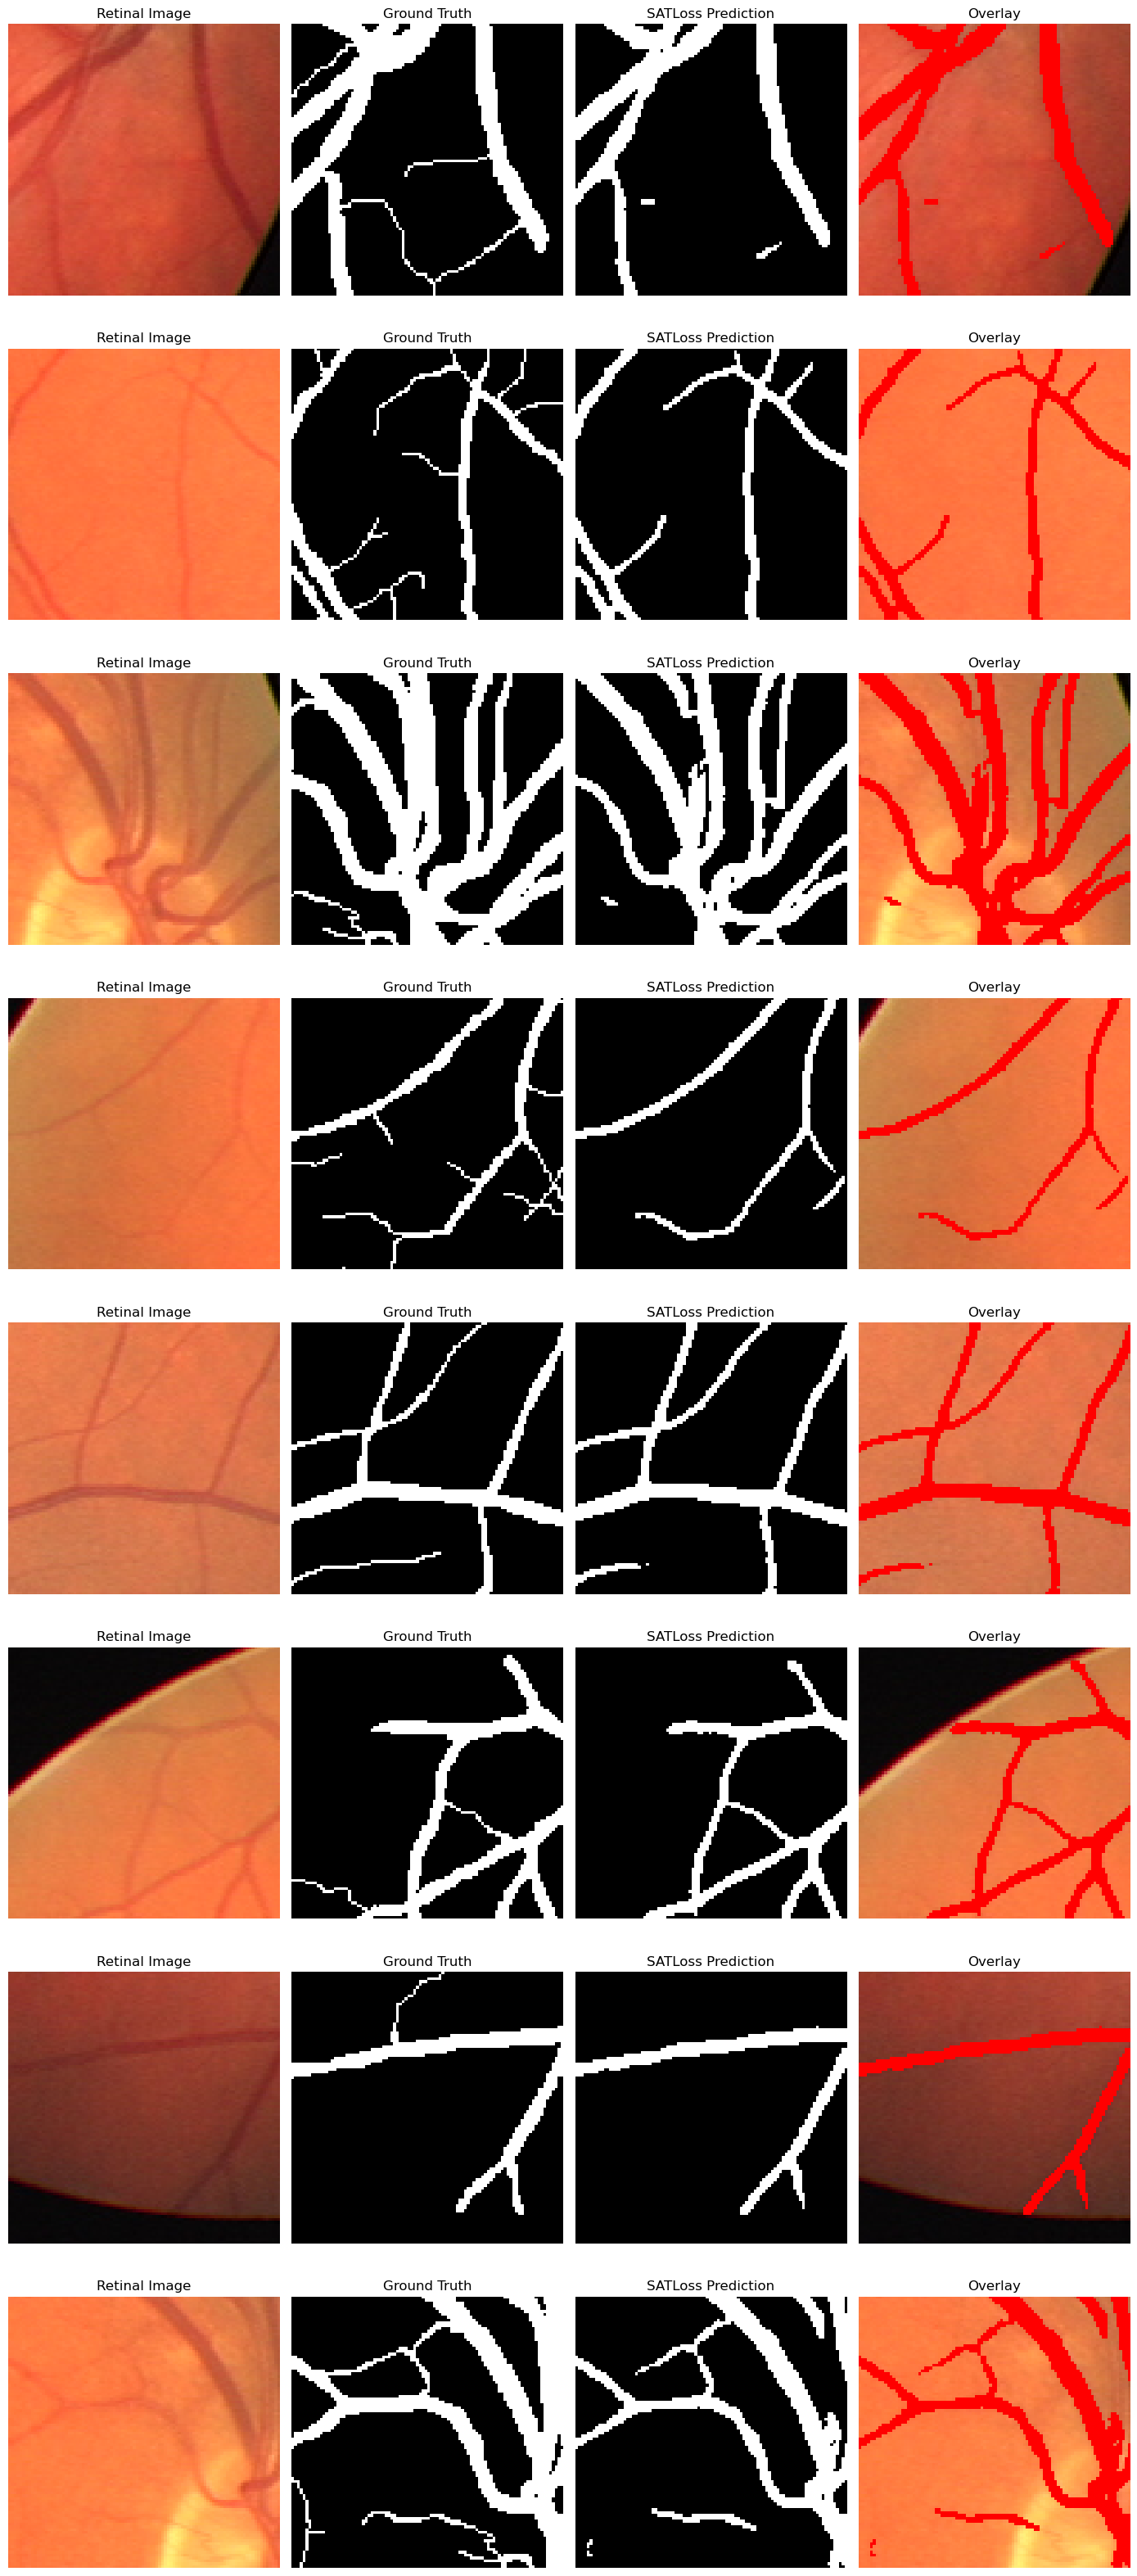


Saved DRIVE + SATLoss prediction visualization to:
drive_transfer_figures/step14_drive_sat_creator_test_predictions.png


In [16]:
# ============================================================
# STEP 14: Visualize DRIVE + SATLoss Creator predictions
# ============================================================

final_drive_sat_model.eval()

vessel_indices = [
    i for i, p in enumerate(test_patches)
    if p["vessel_ratio"] >= 0.08
]

num_samples = 8

selected_indices = random.sample(
    vessel_indices,
    min(num_samples, len(vessel_indices))
)

plt.figure(figsize=(14, 4 * len(selected_indices)))

for row, idx in enumerate(selected_indices):
    patch = test_patches[idx]

    image_patch = patch["image_patch"]
    mask_patch = patch["mask_patch"]

    image_tensor = torch.from_numpy(
        image_patch.astype(np.float32)
    ).permute(2, 0, 1).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = final_drive_sat_model(image_tensor)
        probs = torch.sigmoid(logits)
        pred = (probs > 0.5).float()

    pred_np = pred[0, 0].cpu().numpy().astype(np.uint8)
    mask_np = mask_patch.astype(np.uint8)
    image_display = image_patch.astype(np.float32)

    overlay = image_display.copy()
    overlay[pred_np == 1] = [1.0, 0.0, 0.0]

    print(f"\nPatch {row + 1}")
    print("Image ID:", patch["image_id"])
    print("Location: y =", patch["y"], ", x =", patch["x"])
    print(f"Ground-truth vessel ratio: {patch['vessel_ratio'] * 100:.2f}%")
    print(f"Predicted vessel ratio   : {pred_np.mean() * 100:.2f}%")

    plt.subplot(len(selected_indices), 4, 4 * row + 1)
    plt.imshow(image_display)
    plt.title("Retinal Image")
    plt.axis("off")

    plt.subplot(len(selected_indices), 4, 4 * row + 2)
    plt.imshow(mask_np, cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(len(selected_indices), 4, 4 * row + 3)
    plt.imshow(pred_np, cmap="gray")
    plt.title("SATLoss Prediction")
    plt.axis("off")

    plt.subplot(len(selected_indices), 4, 4 * row + 4)
    plt.imshow(overlay)
    plt.title("Overlay")
    plt.axis("off")

plt.tight_layout()

save_path = os.path.join(
    FIGURE_DIR,
    "step14_drive_sat_creator_test_predictions.png"
)

plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("\nSaved DRIVE + SATLoss prediction visualization to:")
print(save_path)

In [17]:
# ============================================================
# STEP 15: Final DRIVE model comparison table
# ============================================================
# This table summarizes the DRIVE transfer-learning experiment.
#
# Models compared:
#   1. Road Model 5 before DRIVE fine-tuning
#   2. DRIVE transfer learning
#   3. DRIVE transfer learning + SATLoss Creator
# ============================================================

drive_comparison = [
    {
        "Model": "Road Model 5 before fine-tuning",
        "Accuracy": 0.8645,
        "Dice": 0.0000,
        "clDice": None,
        "beta0_error": None,
        "beta1_error": None,
        "Threshold": 0.5000
    },
    {
        "Model": "DRIVE Transfer Learning",
        "Accuracy": drive_test_metrics["accuracy"],
        "Dice": drive_test_metrics["dice"],
        "clDice": drive_test_metrics["cldice"],
        "beta0_error": drive_test_metrics["beta0_error"],
        "beta1_error": drive_test_metrics["beta1_error"],
        "Threshold": drive_test_metrics["threshold"]
    },
    {
        "Model": "DRIVE Transfer Learning + SATLoss Creator",
        "Accuracy": drive_sat_test_metrics["accuracy"],
        "Dice": drive_sat_test_metrics["dice"],
        "clDice": drive_sat_test_metrics["cldice"],
        "beta0_error": drive_sat_test_metrics["beta0_error"],
        "beta1_error": drive_sat_test_metrics["beta1_error"],
        "Threshold": drive_sat_test_metrics["threshold"]
    }
]

drive_comparison_df = pd.DataFrame(drive_comparison)

display(drive_comparison_df.round(4))

drive_comparison_path = os.path.join(
    RESULTS_DIR,
    "final_drive_model_comparison.csv"
)

drive_comparison_df.to_csv(
    drive_comparison_path,
    index=False
)

print("Saved final DRIVE comparison table to:")
print(drive_comparison_path)

,Model,Accuracy,Dice,clDice,beta0_error,beta1_error,Threshold
0,Road Model 5 before fine-tuning,0.8645,0.0000,NaN,NaN,NaN,0.5
1,DRIVE Transfer Learning,0.9518,0.7976,0.7828,1.4179,0.7107,0.5
2,DRIVE Transfer Learning + SATLoss Creator,0.9518,0.7976,0.7828,1.4179,0.7107,0.5


Saved final DRIVE comparison table to:
drive_transfer_results/final_drive_model_comparison.csv


# Whole-image DRIVE prediction using sliding window

Selected full image IDs: ['21', '24', '29', '23', '28']


Predicting full DRIVE images:   0%|          | 0/5 [00:00<?, ?it/s]

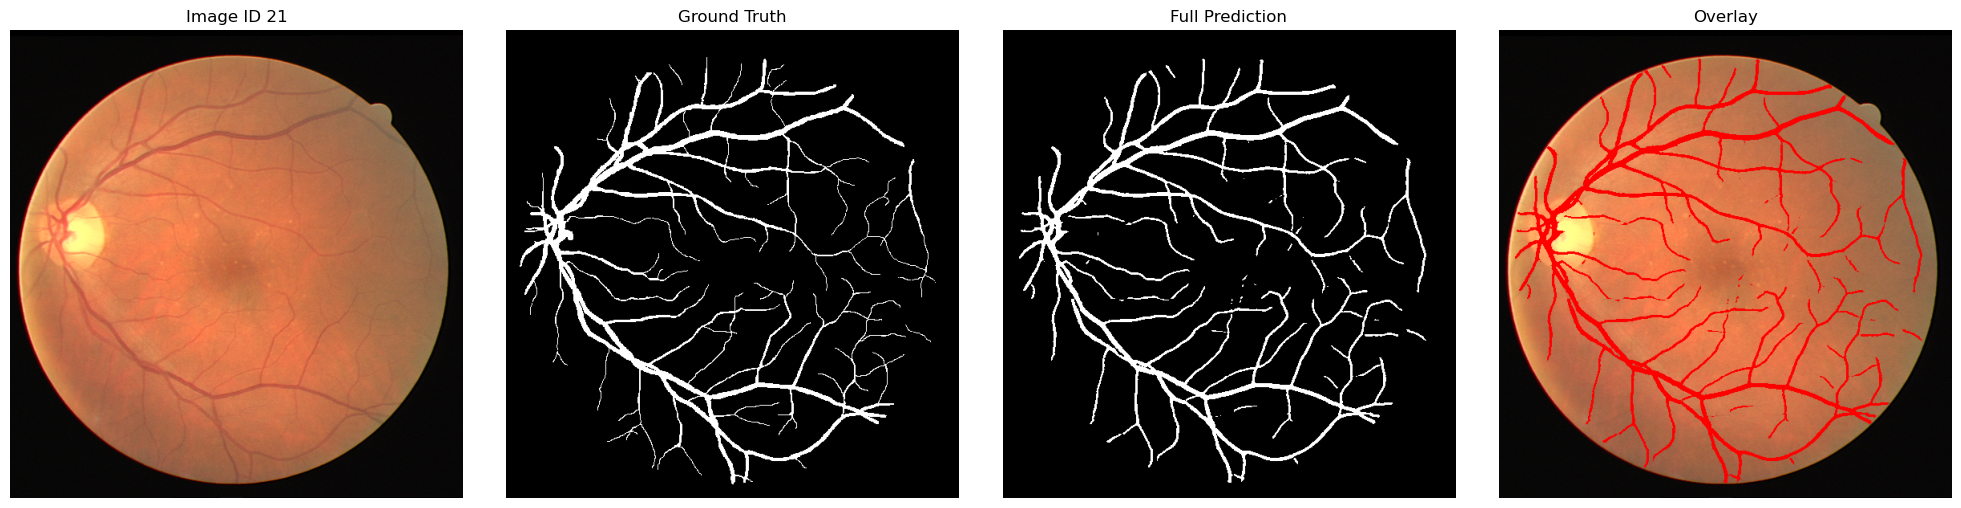

Predicting full DRIVE images:  20%|██        | 1/5 [00:06<00:24,  6.08s/it]


Image ID 21
Accuracy  : 0.9720
Dice      : 0.8196
clDice    : 0.8511
beta0 err : 27
beta1 err : 7
Saved: drive_transfer_figures/step16_drive_full_image_prediction_21.png


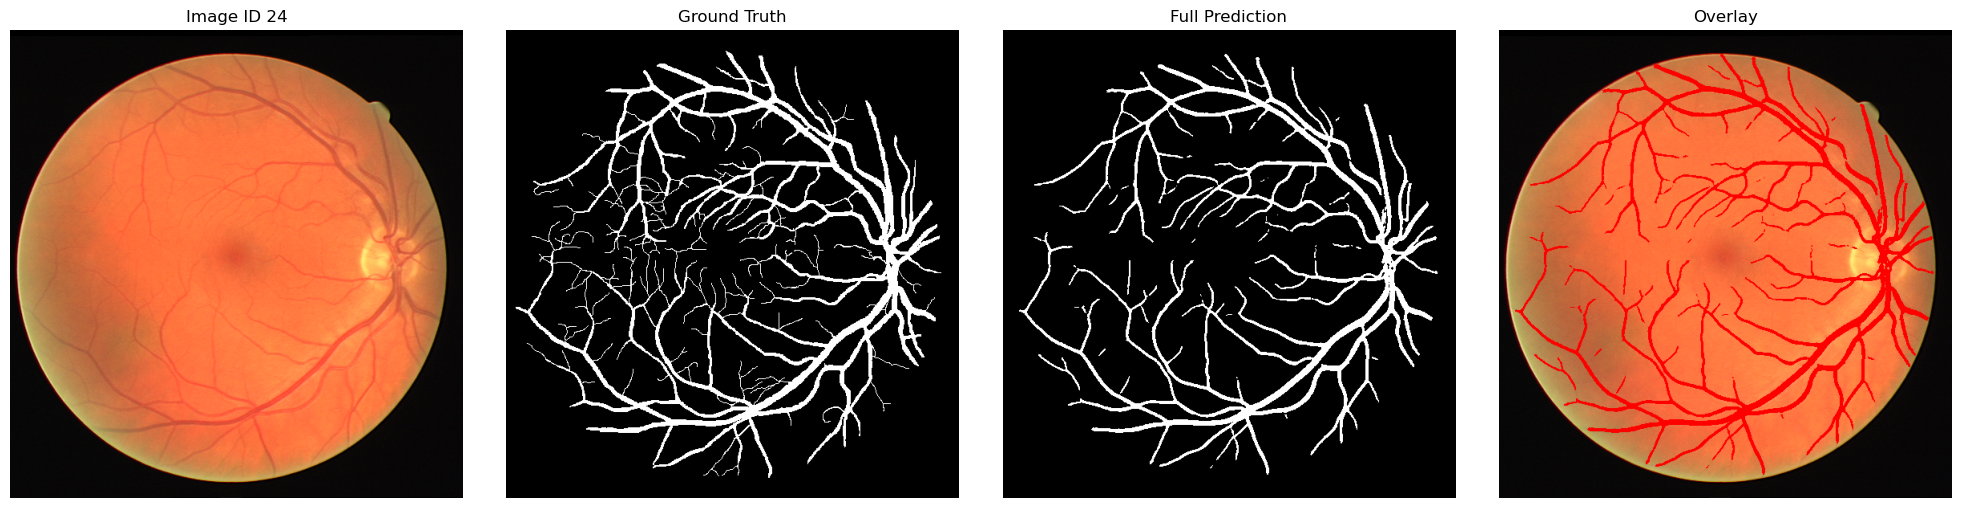

Predicting full DRIVE images:  40%|████      | 2/5 [00:12<00:18,  6.02s/it]


Image ID 24
Accuracy  : 0.9609
Dice      : 0.8149
clDice    : 0.7859
beta0 err : 41
beta1 err : 12
Saved: drive_transfer_figures/step16_drive_full_image_prediction_24.png


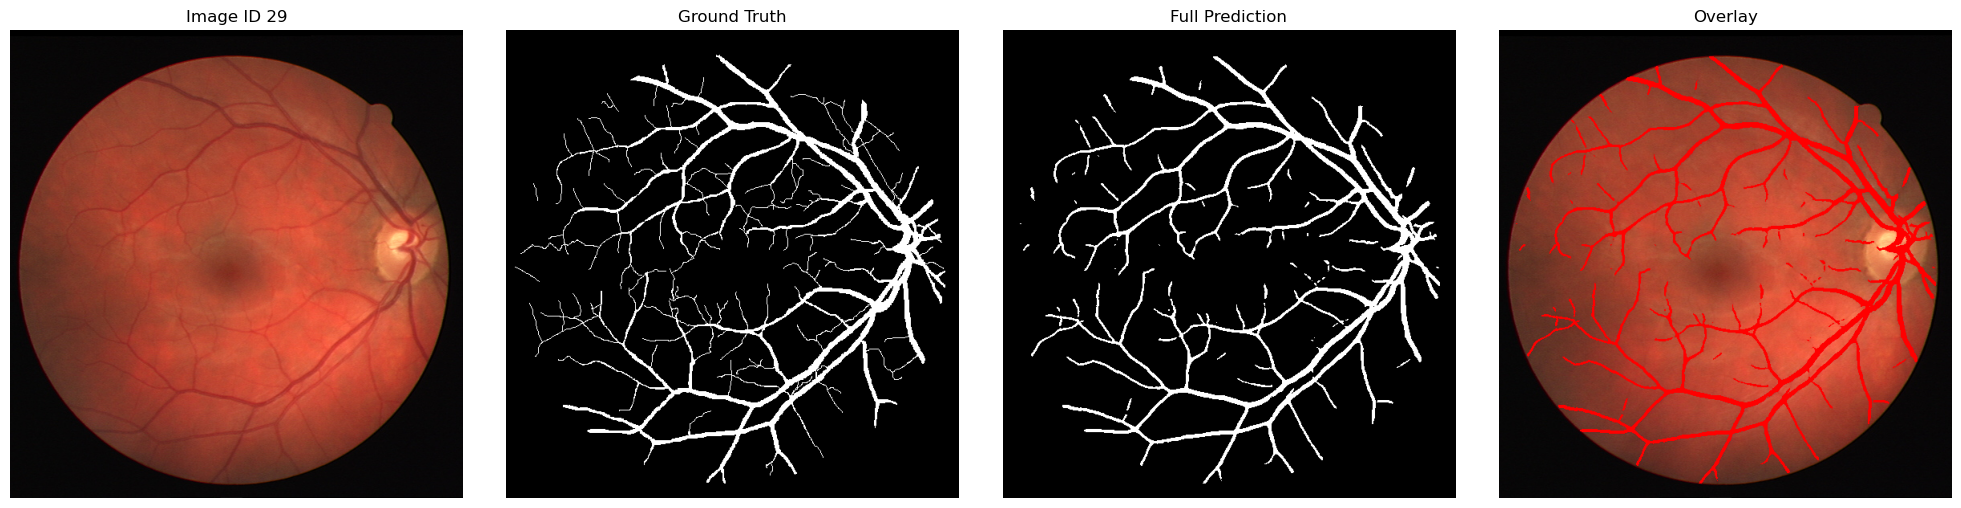

Predicting full DRIVE images:  60%|██████    | 3/5 [00:18<00:12,  6.02s/it]


Image ID 29
Accuracy  : 0.9651
Dice      : 0.7900
clDice    : 0.7596
beta0 err : 49
beta1 err : 12
Saved: drive_transfer_figures/step16_drive_full_image_prediction_29.png


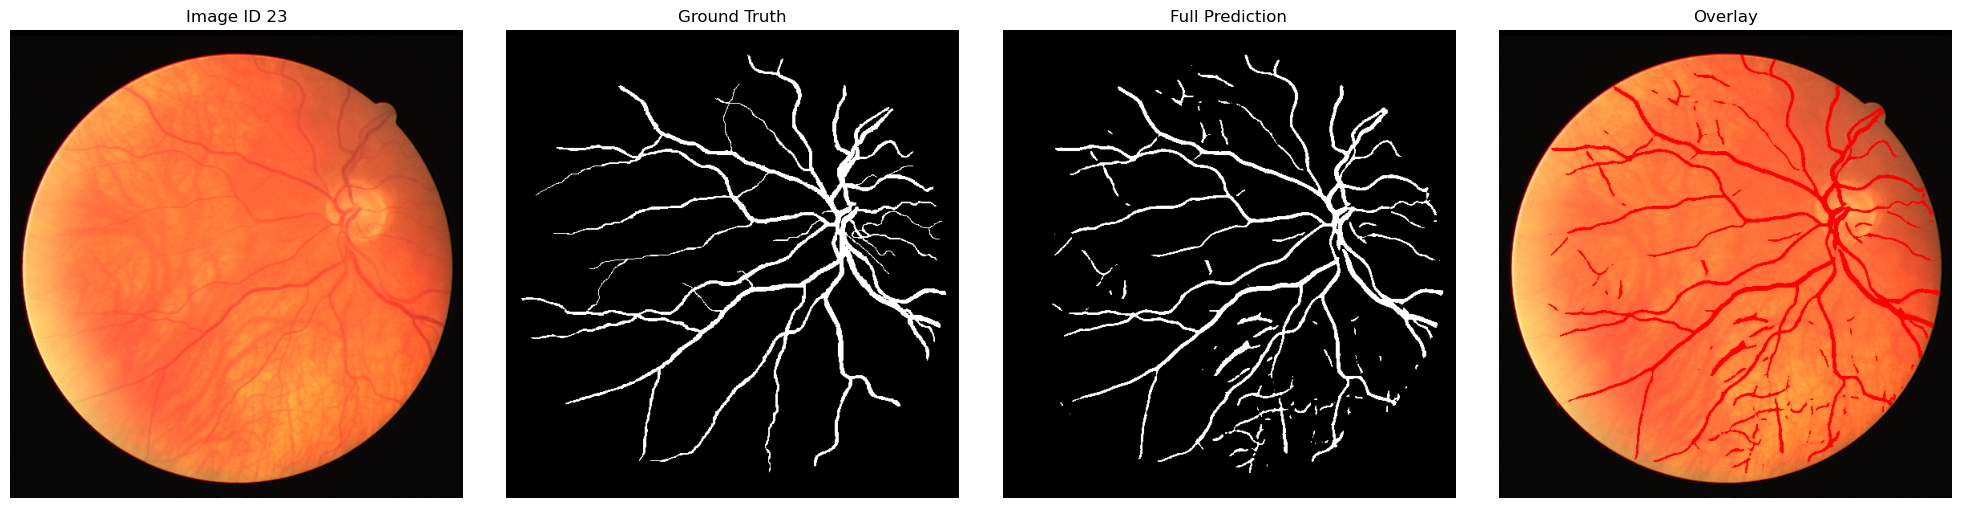

Predicting full DRIVE images:  80%|████████  | 4/5 [00:23<00:05,  5.63s/it]


Image ID 23
Accuracy  : 0.9684
Dice      : 0.7627
clDice    : 0.7895
beta0 err : 86
beta1 err : 15
Saved: drive_transfer_figures/step16_drive_full_image_prediction_23.png


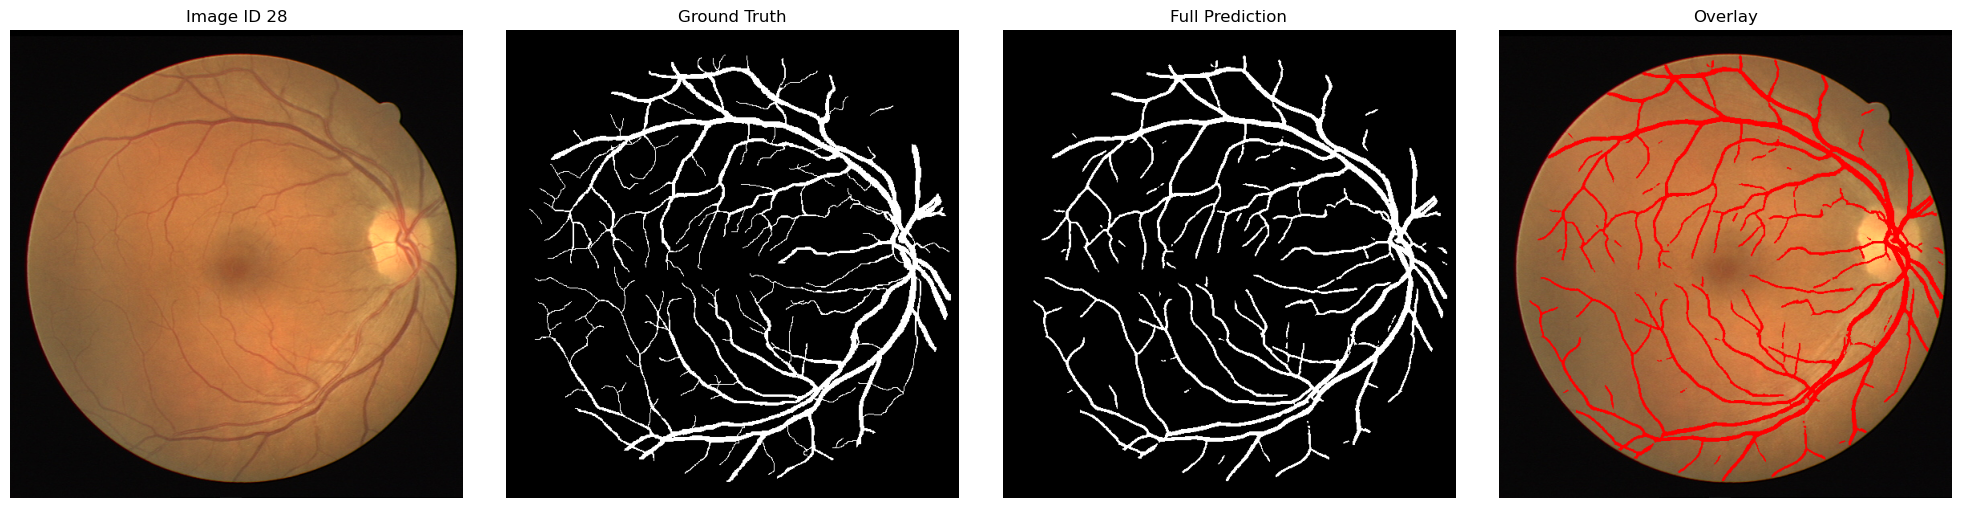

Predicting full DRIVE images: 100%|██████████| 5/5 [00:28<00:00,  5.63s/it]


Image ID 28
Accuracy  : 0.9628
Dice      : 0.8054
clDice    : 0.8187
beta0 err : 48
beta1 err : 23
Saved: drive_transfer_figures/step16_drive_full_image_prediction_28.png


,image_id,accuracy,dice,cldice,beta0_error,beta1_error,threshold
0,21,0.9720,0.8196,0.8511,27,7,0.5
1,24,0.9609,0.8149,0.7859,41,12,0.5
2,29,0.9651,0.7900,0.7596,49,12,0.5
3,23,0.9684,0.7627,0.7895,86,15,0.5
4,28,0.9628,0.8054,0.8187,48,23,0.5



Saved full-image prediction metrics to:
drive_transfer_results/drive_full_image_prediction_metrics.csv


In [19]:
# ============================================================
# STEP 16: Whole-image DRIVE prediction using sliding window
# ============================================================
# This step predicts vessels on a full DRIVE retinal image.
#
# Procedure:
#   1. Load one full retinal image.
#   2. Cut it into overlapping 96x96 patches.
#   3. Predict each patch using the final DRIVE model.
#   4. Stitch patch probabilities back into a full-size probability map.
#   5. Threshold the probability map to obtain the final vessel mask.
#
# This gives a full-image vessel prediction for thesis visualization.
# ============================================================

final_drive_model.eval()

NUM_FULL_IMAGES = 5
THRESHOLD = 0.5

# Use all test images first, then add validation images if fewer than 5
available_ids = sorted(list(test_image_ids))

if len(available_ids) < NUM_FULL_IMAGES:
    available_ids = available_ids + sorted(list(val_image_ids))

selected_full_image_ids = available_ids[:NUM_FULL_IMAGES]

print("Selected full image IDs:", selected_full_image_ids)


def predict_full_drive_image(model, pair, threshold=0.5):
    full_image = Image.open(pair["image_path"]).convert("RGB")
    full_mask = Image.open(pair["vessel_mask_path"]).convert("L")
    full_fov = Image.open(pair["fov_mask_path"]).convert("L")

    full_image_np = np.array(full_image).astype(np.float32) / 255.0
    full_mask_np = (np.array(full_mask) > 0).astype(np.uint8)
    full_fov_np = (np.array(full_fov) > 0).astype(np.uint8)

    H, W = full_mask_np.shape

    prob_sum = np.zeros((H, W), dtype=np.float32)
    count_map = np.zeros((H, W), dtype=np.float32)

    y_positions = list(range(0, H - PATCH_SIZE + 1, STRIDE))
    x_positions = list(range(0, W - PATCH_SIZE + 1, STRIDE))

    if y_positions[-1] != H - PATCH_SIZE:
        y_positions.append(H - PATCH_SIZE)

    if x_positions[-1] != W - PATCH_SIZE:
        x_positions.append(W - PATCH_SIZE)

    with torch.no_grad():
        for y in y_positions:
            for x in x_positions:
                image_patch = full_image_np[
                    y:y + PATCH_SIZE,
                    x:x + PATCH_SIZE,
                    :
                ]

                image_tensor = torch.from_numpy(
                    image_patch.astype(np.float32)
                ).permute(2, 0, 1).unsqueeze(0).to(device)

                logits = model(image_tensor)
                probs = torch.sigmoid(logits)

                prob_patch = probs[0, 0].cpu().numpy()

                prob_sum[
                    y:y + PATCH_SIZE,
                    x:x + PATCH_SIZE
                ] += prob_patch

                count_map[
                    y:y + PATCH_SIZE,
                    x:x + PATCH_SIZE
                ] += 1.0

    full_prob = prob_sum / np.maximum(count_map, 1e-8)
    full_prob = full_prob * full_fov_np

    full_pred = (full_prob > threshold).astype(np.uint8)

    full_acc = (full_pred == full_mask_np).mean()

    intersection = (full_pred * full_mask_np).sum()
    dice_full = (
        2.0 * intersection + 1e-8
    ) / (
        full_pred.sum() + full_mask_np.sum() + 1e-8
    )

    full_cldice = cldice_score(
        full_pred,
        full_mask_np
    )

    full_b0_err, full_b1_err = betti_error(
        full_pred,
        full_mask_np
    )

    return {
        "image_np": full_image_np,
        "mask_np": full_mask_np,
        "pred_np": full_pred,
        "prob_np": full_prob,
        "accuracy": full_acc,
        "dice": dice_full,
        "cldice": full_cldice,
        "beta0_error": full_b0_err,
        "beta1_error": full_b1_err
    }


full_image_results = []

for image_id in tqdm(selected_full_image_ids, desc="Predicting full DRIVE images"):

    pair = None
    for p in drive_pairs:
        if p["image_id"] == image_id:
            pair = p
            break

    if pair is None:
        print("Skipping missing image ID:", image_id)
        continue

    result = predict_full_drive_image(
        final_drive_model,
        pair,
        threshold=THRESHOLD
    )

    full_image_results.append({
        "image_id": image_id,
        "accuracy": result["accuracy"],
        "dice": result["dice"],
        "cldice": result["cldice"],
        "beta0_error": result["beta0_error"],
        "beta1_error": result["beta1_error"],
        "threshold": THRESHOLD
    })

    overlay = result["image_np"].copy()
    overlay[result["pred_np"] == 1] = [1.0, 0.0, 0.0]

    plt.figure(figsize=(20, 5))

    plt.subplot(1, 4, 1)
    plt.imshow(result["image_np"])
    plt.title(f"Image ID {image_id}")
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(result["mask_np"], cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(result["pred_np"], cmap="gray")
    plt.title("Full Prediction")
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.imshow(overlay)
    plt.title("Overlay")
    plt.axis("off")

    plt.tight_layout()

    save_path = os.path.join(
        FIGURE_DIR,
        f"step16_drive_full_image_prediction_{image_id}.png"
    )

    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"\nImage ID {image_id}")
    print(f"Accuracy  : {result['accuracy']:.4f}")
    print(f"Dice      : {result['dice']:.4f}")
    print(f"clDice    : {result['cldice']:.4f}")
    print(f"beta0 err : {result['beta0_error']}")
    print(f"beta1 err : {result['beta1_error']}")
    print("Saved:", save_path)


# ----------------------------
# Save full-image metric summary
# ----------------------------
full_image_results_df = pd.DataFrame(full_image_results)

display(full_image_results_df.round(4))

full_image_results_path = os.path.join(
    RESULTS_DIR,
    "drive_full_image_prediction_metrics.csv"
)

full_image_results_df.to_csv(
    full_image_results_path,
    index=False
)

print("\nSaved full-image prediction metrics to:")
print(full_image_results_path)

In [20]:
# ============================================================
# STEP 17: Save final DRIVE model, history, and summary
# ============================================================
# This step saves the important outputs from the DRIVE experiment:
#   1. Final best transfer model
#   2. Training history
#   3. Patch-level test results
#   4. Full-image prediction results
#   5. Experiment summary for thesis reporting
# ============================================================

# ----------------------------
# Save final best DRIVE model
# ----------------------------
final_drive_model_path = os.path.join(
    SAVE_DIR,
    "final_drive_transfer_from_road_model5.pth"
)

torch.save(
    final_drive_model.state_dict(),
    final_drive_model_path
)

print("Saved final DRIVE model to:")
print(final_drive_model_path)


# ----------------------------
# Save DRIVE training history
# ----------------------------
drive_history_path = os.path.join(
    RESULTS_DIR,
    "drive_training_history.pkl"
)

with open(drive_history_path, "wb") as f:
    pickle.dump(drive_history, f)

print("\nSaved DRIVE training history to:")
print(drive_history_path)


# ----------------------------
# Save DRIVE SATLoss history if available
# ----------------------------
if "drive_sat_history" in globals():

    drive_sat_history_path = os.path.join(
        RESULTS_DIR,
        "drive_sat_creator_training_history.pkl"
    )

    with open(drive_sat_history_path, "wb") as f:
        pickle.dump(drive_sat_history, f)

    print("\nSaved DRIVE SATLoss training history to:")
    print(drive_sat_history_path)


# ----------------------------
# Save experiment summary
# ----------------------------
drive_summary = {
    "source_model": "Road Model 5: BCE + Dice + clDice + SATLoss Creator",
    "target_dataset": "DRIVE retinal vessel segmentation",
    "patch_size": PATCH_SIZE,
    "stride": STRIDE,
    "batch_size": BATCH_SIZE,
    "train_patches": len(train_patches),
    "val_patches": len(val_patches),
    "test_patches": len(test_patches),
    "best_validation_dice": best_drive_dice,
    "patch_test_metrics": drive_test_metrics,
    "satloss_test_metrics": drive_sat_test_metrics,
    "pretrained_model_path": PRETRAINED_ROAD_MODEL_PATH,
    "final_model_path": final_drive_model_path
}

if "full_image_results_df" in globals():
    drive_summary["full_image_metrics_mean"] = {
        "accuracy": float(full_image_results_df["accuracy"].mean()),
        "dice": float(full_image_results_df["dice"].mean()),
        "cldice": float(full_image_results_df["cldice"].mean()),
        "beta0_error": float(full_image_results_df["beta0_error"].mean()),
        "beta1_error": float(full_image_results_df["beta1_error"].mean())
    }

summary_path = os.path.join(
    RESULTS_DIR,
    "drive_transfer_experiment_summary.json"
)

with open(summary_path, "w") as f:
    json.dump(drive_summary, f, indent=4)

print("\nSaved DRIVE experiment summary to:")
print(summary_path)


# ----------------------------
# Print short final summary
# ----------------------------
print("\nFINAL DRIVE SUMMARY")
print("-------------------")
print(f"Patch Test Accuracy : {drive_test_metrics['accuracy']:.4f}")
print(f"Patch Test Dice     : {drive_test_metrics['dice']:.4f}")
print(f"Patch Test clDice   : {drive_test_metrics['cldice']:.4f}")
print(f"Patch Test beta0 err: {drive_test_metrics['beta0_error']:.4f}")
print(f"Patch Test beta1 err: {drive_test_metrics['beta1_error']:.4f}")

if "full_image_results_df" in globals():
    print("\nFull-image mean results")
    print("-----------------------")
    print(f"Mean Accuracy : {full_image_results_df['accuracy'].mean():.4f}")
    print(f"Mean Dice     : {full_image_results_df['dice'].mean():.4f}")
    print(f"Mean clDice   : {full_image_results_df['cldice'].mean():.4f}")
    print(f"Mean beta0 err: {full_image_results_df['beta0_error'].mean():.4f}")
    print(f"Mean beta1 err: {full_image_results_df['beta1_error'].mean():.4f}")

Saved final DRIVE model to:
drive_transfer_models/final_drive_transfer_from_road_model5.pth

Saved DRIVE training history to:
drive_transfer_results/drive_training_history.pkl

Saved DRIVE SATLoss training history to:
drive_transfer_results/drive_sat_creator_training_history.pkl

Saved DRIVE experiment summary to:
drive_transfer_results/drive_transfer_experiment_summary.json

FINAL DRIVE SUMMARY
-------------------
Patch Test Accuracy : 0.9518
Patch Test Dice     : 0.7976
Patch Test clDice   : 0.7828
Patch Test beta0 err: 1.4179
Patch Test beta1 err: 0.7107

Full-image mean results
-----------------------
Mean Accuracy : 0.9658
Mean Dice     : 0.7985
Mean clDice   : 0.8010
Mean beta0 err: 50.2000
Mean beta1 err: 13.8000
